# Stage 2 HOLD & Extreme Move Analysis

This notebook mirrors the Stage 1 charting style (`data/charts`) but focuses on Stage 2 outputs. It surfaces HOLD distribution, forward-return extremes, and alpha/beta sensitivity while saving all charts to disk for easy sharing.


## Goals
- Load Stage 2 configs and artifacts (processed OHLCV, datasets, reports)
- Recreate the chart set from `data/charts`: forward return distributions, alpha/beta sensitivity, label heatmaps, recent candles, window examples
- Quantify HOLD distribution across pairs/windows and highlight extreme return percentiles
- Save every plot to `data/charts_stage2/`


In [1]:
# %pip install pandas pyarrow matplotlib seaborn pyyaml tqdm


In [2]:
from __future__ import annotations

import json
import re
from pathlib import Path
from typing import Any, Dict, List

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from tqdm.notebook import tqdm

try:
    from IPython.display import Image, display
    HAS_IPY = True
except ImportError:  # pragma: no cover - optional in non-notebook runs
    HAS_IPY = False
    Image = None
    display = None

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 140,
})
plt.switch_backend("Agg")  # allow saving without GUI


In [3]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "configs").exists() else NOTEBOOK_DIR.parent
LABEL_CFG_PATH = PROJECT_ROOT / "configs" / "labeling_stage2.yaml"
PATH_CFG_PATH = PROJECT_ROOT / "configs" / "paths_stage2.yaml"
OUTPUT_DIR = PROJECT_ROOT / "data" / "charts_stage2"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DISPLAY_PLOTS = True  # show saved charts inline when running in a notebook

print(f"Project root: {PROJECT_ROOT}")
print(f"Charts will be saved to: {OUTPUT_DIR}")


Project root: /home/kamil/binance-bot
Charts will be saved to: /home/kamil/binance-bot/data/charts_stage2


In [4]:
def load_yaml(path: Path) -> Dict[str, Any]:
    if not path.exists():
        raise FileNotFoundError(f"Missing config: {path}")
    with path.open("r", encoding="utf-8") as handle:
        payload = yaml.safe_load(handle) or {}
    if not isinstance(payload, dict):
        raise ValueError(f"Expected mapping in {path}, got {type(payload).__name__}")
    return payload


def load_reports(report_dir: Path) -> pd.DataFrame:
    records = []
    for path in sorted(report_dir.glob("*.json")):
        with path.open("r", encoding="utf-8") as handle:
            payload = json.load(handle)
        counts = payload.get("counts", {})
        dist = payload.get("distribution", {})
        record = {
            "symbol": payload.get("symbol"),
            "interval": payload.get("interval"),
            "backW": int(payload.get("backW", 0)),
            "forW": int(payload.get("forW", 0)),
            "alpha": float(payload.get("alpha", 0.0)),
            "beta": float(payload.get("beta", 0.0)),
            "dataset_path": payload.get("dataset_path"),
            "n_valid": int(payload.get("n_valid", 0)),
            "n_total": int(payload.get("n_total", 0)),
            "buy": int(counts.get("BUY", 0)),
            "hold": int(counts.get("HOLD", 0)),
            "sell": int(counts.get("SELL", 0)),
            "nan": int(counts.get("NaN", 0)),
            "share_buy": float(dist.get("BUY", 0.0)),
            "share_hold": float(dist.get("HOLD", 0.0)),
            "share_sell": float(dist.get("SELL", 0.0)),
        }
        record["window"] = f"backW{record['backW']}_forW{record['forW']}"
        records.append(record)
    df = pd.DataFrame(records)
    if df.empty:
        raise FileNotFoundError(f"No JSON reports found in {report_dir}")
    return df


def savefig(fig: plt.Figure, name: str, *, show: bool = True) -> None:
    path = OUTPUT_DIR / name
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved {path}")
    if show and DISPLAY_PLOTS and HAS_IPY:
        display(Image(filename=str(path)))


def sample_series(series: pd.Series, max_points: int | None, *, seed: int = 7) -> pd.Series:
    """Downsample large series for plotting without changing stats."""
    if max_points is None or len(series) <= max_points:
        return series
    return series.sample(max_points, random_state=seed)


def parquet_row_count(path: Path) -> int:
    try:
        import pyarrow.parquet as pq
    except ImportError:
        return len(pd.read_parquet(path, columns=["open"]))
    try:
        return pq.ParquetFile(path).metadata.num_rows
    except Exception:
        return len(pd.read_parquet(path, columns=["open"]))


In [5]:
label_cfg = load_yaml(LABEL_CFG_PATH)
paths_cfg = load_yaml(PATH_CFG_PATH)

interval = str(label_cfg["interval"])
interval_safe = interval.replace("/", "-")
fee = float(label_cfg.get("fee", 0.0))
backW_values = [int(v) for v in label_cfg.get("backW", [])]
forW_values = [int(v) for v in label_cfg.get("forW", [])]
single_pct = label_cfg.get("single_candle_percentiles", {"alpha_pct": 0.25, "beta_pct": 0.997})

DEFAULT_BACKW = 5
DEFAULT_FORW = 2
if DEFAULT_BACKW not in backW_values and backW_values:
    DEFAULT_BACKW = max(backW_values)
    print(f"Default backW=5 missing; using backW={DEFAULT_BACKW} instead.")
if DEFAULT_FORW not in forW_values and forW_values:
    DEFAULT_FORW = min(forW_values)
    print(f"Default forW=2 missing; using forW={DEFAULT_FORW} instead.")

REPORTS_DIR = (PROJECT_ROOT / paths_cfg["reports_dir"]).expanduser().resolve()
DATASETS_DIR = (PROJECT_ROOT / paths_cfg["datasets_dir"]).expanduser().resolve()
PROCESSED_DIR = (PROJECT_ROOT / paths_cfg["processed_dir"]).expanduser().resolve()

PROCESSED_FILES = sorted(PROCESSED_DIR.glob(f"*_{interval_safe}.parquet"))
DATASET_FILES = sorted(DATASETS_DIR.glob(f"*_{interval_safe}_backW*_forW*.parquet"))
REPORT_FILES = sorted(REPORTS_DIR.glob(f"*_{interval_safe}_backW*_forW*.json"))

print(f"Interval={interval} | backW={backW_values} | forW={forW_values} | fee={fee}")
print(f"Default window: backW={DEFAULT_BACKW} | forW={DEFAULT_FORW}")
print(f"Reports:  {REPORTS_DIR}")
print(f"Datasets: {DATASETS_DIR}")
print(f"Processed:{PROCESSED_DIR}")
print(f"Processed files: {len(PROCESSED_FILES)}")
print(f"Dataset files:   {len(DATASET_FILES)}")
print(f"Report files:    {len(REPORT_FILES)}")


Interval=4h | backW=[1, 2, 3, 4, 5] | forW=[1, 2, 3, 4, 5] | fee=0.001
Default window: backW=5 | forW=2
Reports:  /home/kamil/binance-bot/stage1/stage2_data/reports
Datasets: /home/kamil/binance-bot/stage1/stage2_data/datasets
Processed:/home/kamil/binance-bot/stage1/stage2_data/processed
Processed files: 438
Dataset files:   10881
Report files:    10881


In [6]:
report_df = load_reports(REPORTS_DIR)
report_df.head()


,symbol,interval,backW,forW,alpha,beta,dataset_path,n_valid,n_total,buy,hold,sell,nan,share_buy,share_hold,share_sell,window
0,0GUSDT,4h,1,1,0.041944,0.203349,/home/kamil/binance-bot/stage1/stage2_data/dat...,524,524,44,383,97,0,0.083969,0.730916,0.185115,backW1_forW1
1,0GUSDT,4h,1,2,0.041944,0.223684,/home/kamil/binance-bot/stage1/stage2_data/dat...,523,523,62,339,122,0,0.118547,0.648184,0.233270,backW1_forW2
2,0GUSDT,4h,1,3,0.041944,0.244019,/home/kamil/binance-bot/stage1/stage2_data/dat...,522,522,66,294,162,0,0.126437,0.563218,0.310345,backW1_forW3
3,0GUSDT,4h,1,4,0.041944,0.264354,/home/kamil/binance-bot/stage1/stage2_data/dat...,521,521,64,269,188,0,0.122841,0.516315,0.360845,backW1_forW4
4,0GUSDT,4h,1,5,0.041944,0.284689,/home/kamil/binance-bot/stage1/stage2_data/dat...,520,520,59,243,218,0,0.113462,0.467308,0.419231,backW1_forW5


## Stage 2 snapshot
Window-level roll-up (backW/forW) plus processed OHLCV totals.


In [7]:
processed_symbols = {path.stem.split("_")[0] for path in PROCESSED_FILES}
report_symbols = set(report_df["symbol"].dropna().unique())
missing_reports = sorted(processed_symbols - report_symbols)

alpha_by_forW = report_df.groupby("forW")["alpha"].median().sort_index()
beta_by_forW = report_df.groupby("forW")["beta"].median().sort_index()

window_summary = (
    report_df
    .groupby(["backW", "forW"])
    .agg(
        symbols=("symbol", "nunique"),
        rows=("symbol", "size"),
        buy=("buy", "sum"),
        hold=("hold", "sum"),
        sell=("sell", "sum"),
        avg_hold_share=("share_hold", "mean"),
        median_hold_share=("share_hold", "median"),
    )
    .reset_index()
    .sort_values(["backW", "forW"])
)
window_summary["total_labels"] = window_summary[["buy", "hold", "sell"]].sum(axis=1)
window_summary["share_buy"] = window_summary["buy"] / window_summary["total_labels"]
window_summary["share_hold"] = window_summary["hold"] / window_summary["total_labels"]
window_summary["share_sell"] = window_summary["sell"] / window_summary["total_labels"]

window_alpha_beta = (
    report_df
    .groupby(["backW", "forW"])[["alpha", "beta"]]
    .median()
    .reset_index()
)

processed_rows_total = int(sum(parquet_row_count(path) for path in PROCESSED_FILES)) if PROCESSED_FILES else 0
snapshot_stats = pd.DataFrame([{
    "processed_rows_total": processed_rows_total,
    "symbols_processed": len(processed_symbols),
    "symbols_reports": report_df["symbol"].nunique(),
    "windows": window_summary.shape[0],
}])

if missing_reports:
    print(f"Processed symbols without reports: {missing_reports}")

if HAS_IPY:
    display(snapshot_stats)
    display(window_summary)
else:
    print(snapshot_stats)
    print(window_summary.head(10))


Processed symbols without reports: ['FTTUSDT', 'USDPUSDT']


,processed_rows_total,symbols_processed,symbols_reports,windows
0,3061820,438,436,25


,backW,forW,symbols,rows,buy,hold,sell,avg_hold_share,median_hold_share,total_labels,share_buy,share_hold,share_sell
0,1,1,435,435,192508,2593961,243566,0.839856,0.840695,3030035,0.063533,0.856083,0.080384
1,1,2,435,435,269228,2420767,339605,0.777825,0.775949,3029600,0.088866,0.799038,0.112096
2,1,3,435,435,335028,2271529,422608,0.725516,0.722910,3029165,0.110601,0.749886,0.139513
3,1,4,435,435,394207,2140142,494381,0.680805,0.677946,3028730,0.130156,0.706614,0.163230
4,1,5,435,435,445424,2026985,555886,0.642583,0.638200,3028295,0.147087,0.669349,0.183564
5,2,1,435,435,192458,2593611,243531,0.839832,0.840671,3029600,0.063526,0.856090,0.080384
6,2,2,435,435,269171,2420419,339575,0.777801,0.776003,3029165,0.088860,0.799038,0.112102
7,2,3,435,435,334957,2271203,422570,0.725485,0.723061,3028730,0.110593,0.749886,0.139521
8,2,4,435,435,394131,2139824,494340,0.680765,0.677913,3028295,0.130149,0.706610,0.163240
9,2,5,435,435,445346,2026670,555844,0.642513,0.638153,3027860,0.147083,0.669341,0.183577


Saved /home/kamil/binance-bot/data/charts_stage2/stage2_label_mix_overview.png


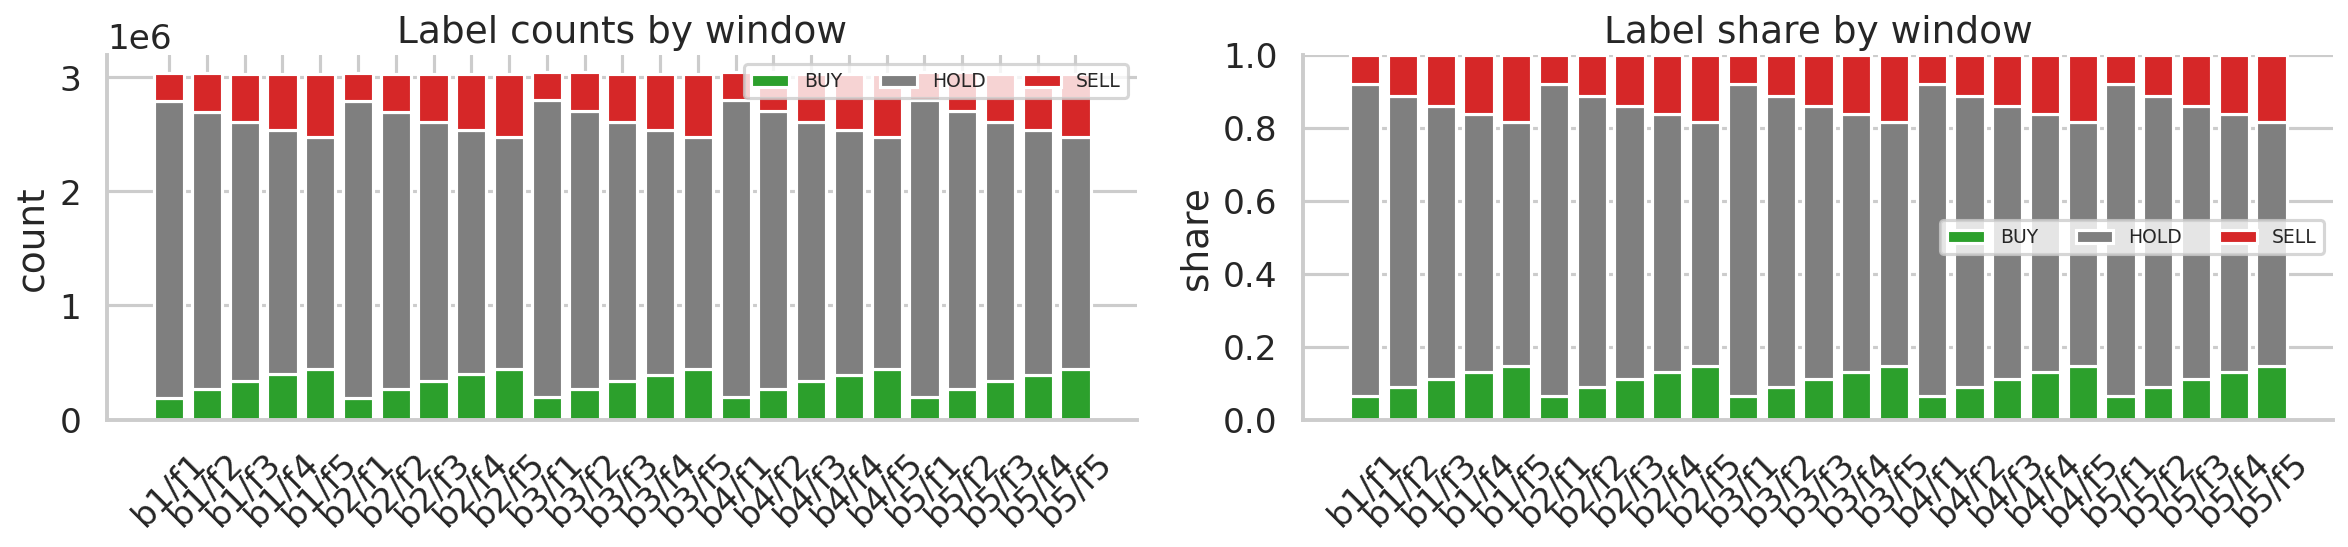

In [8]:
window_labels = window_summary.apply(
    lambda r: f"b{int(r['backW'])}/f{int(r['forW'])}", axis=1
)
window_counts = window_summary[["buy", "hold", "sell"]].copy()
window_counts.index = window_labels
window_shares = window_counts.div(window_counts.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
colors = {"BUY": "#2ca02c", "HOLD": "#7f7f7f", "SELL": "#d62728"}

bottom = np.zeros(len(window_counts))
for label in ["BUY", "HOLD", "SELL"]:
    values = window_counts[label.lower()].values
    axes[0].bar(window_counts.index, values, bottom=bottom, label=label, color=colors[label])
    bottom += values
axes[0].set_title("Label counts by window")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(ncol=3, fontsize=9)

bottom = np.zeros(len(window_shares))
for label in ["BUY", "HOLD", "SELL"]:
    values = window_shares[label.lower()].values
    axes[1].bar(window_shares.index, values, bottom=bottom, label=label, color=colors[label])
    bottom += values
axes[1].set_title("Label share by window")
axes[1].set_ylabel("share")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(ncol=3, fontsize=9)

savefig(fig, "stage2_label_mix_overview.png")


## Data availability over time
Histogram of raw OHLCV rows (processed) through time, plus cumulative coverage.


Aggregating OHLCV coverage:   0%|          | 0/438 [00:00<?, ?it/s]

Saved /home/kamil/binance-bot/data/charts_stage2/data_availability_over_time.png


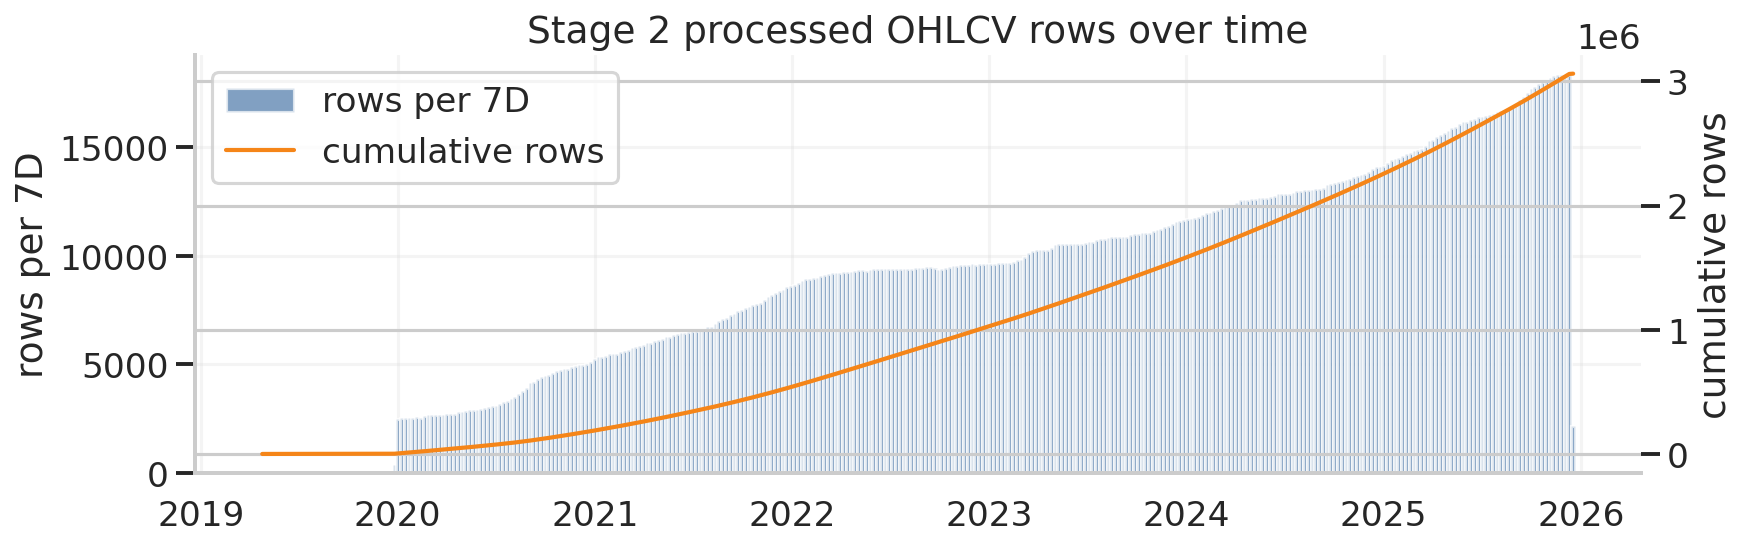

In [9]:
MAX_PROCESSED = None  # set to an int to limit processing
AVAIL_FREQ = "7D"

_processed_files = PROCESSED_FILES
if MAX_PROCESSED:
    _processed_files = _processed_files[:MAX_PROCESSED]
if not _processed_files:
    raise FileNotFoundError(f"No processed parquet files found in {PROCESSED_DIR}")

availability_counts = {}
for path in tqdm(_processed_files, desc="Aggregating OHLCV coverage"):
    df = pd.read_parquet(path, columns=["open"])
    ts = pd.to_datetime(df.index, utc=True)
    if ts.empty:
        continue
    buckets = ts.floor(AVAIL_FREQ).value_counts()
    for bucket, value in buckets.items():
        availability_counts[bucket] = availability_counts.get(bucket, 0) + int(value)

availability = pd.Series(availability_counts).sort_index()
availability = availability[availability.index.notna()]
if availability.empty:
    raise ValueError("No availability data was aggregated.")

availability_cum = availability.cumsum()

fig, ax = plt.subplots(figsize=(12, 4))
bar_width = pd.Timedelta(AVAIL_FREQ)
ax.bar(availability.index, availability.values, width=bar_width, color="#4c78a8", alpha=0.7, label=f"rows per {AVAIL_FREQ}")
ax.set_title("Stage 2 processed OHLCV rows over time")
ax.set_ylabel(f"rows per {AVAIL_FREQ}")
ax.grid(True, alpha=0.2)

ax2 = ax.twinx()
ax2.plot(availability.index, availability_cum.values, color="#f58518", lw=2, label="cumulative rows")
ax2.set_ylabel("cumulative rows")

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="upper left")

savefig(fig, "data_availability_over_time.png")


## HOLD distribution
Comparison of HOLD share distributions for backW=5 with forW=2 vs forW=4.


Saved /home/kamil/binance-bot/data/charts_stage2/hold_share_hist.png


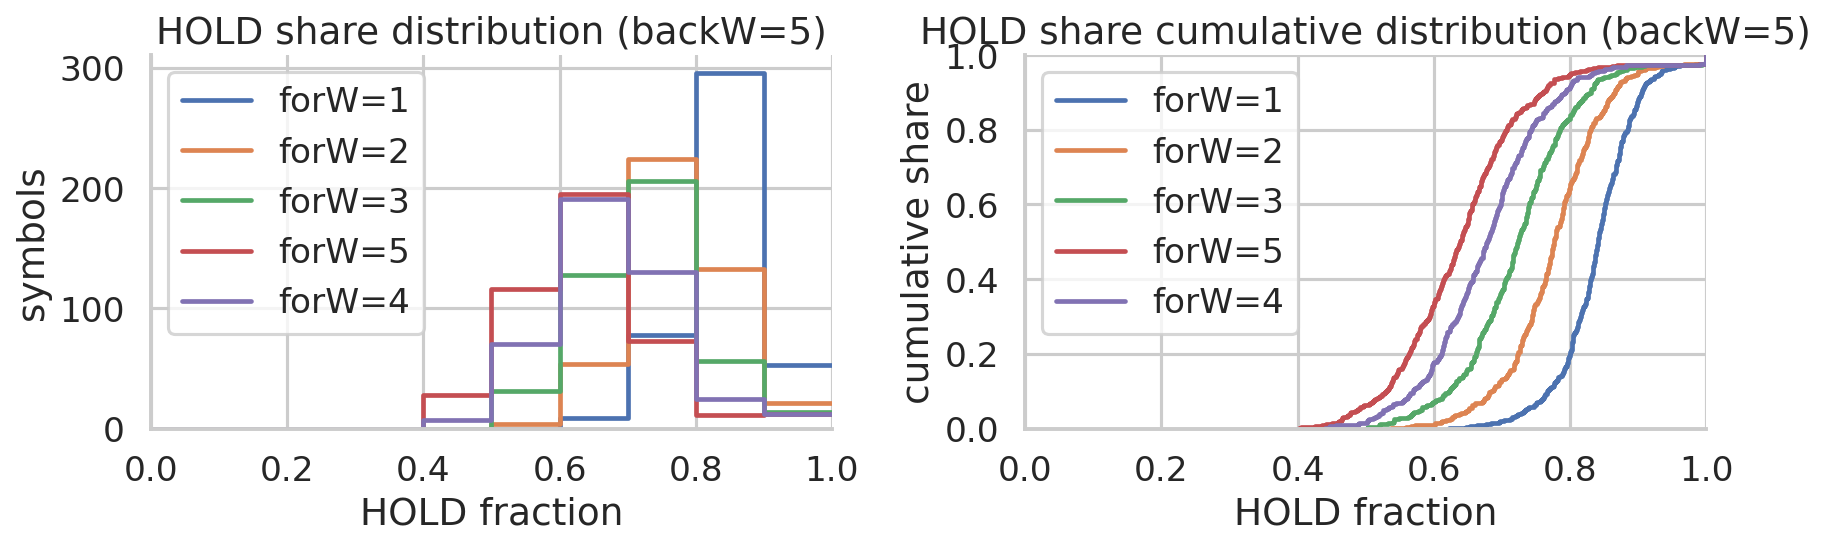

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

compare_forW = [1,DEFAULT_FORW, 3,5,4]
compare_forW = [w for w in compare_forW if w in forW_values]
if len(compare_forW) < 2:
    raise ValueError("Need forW=2 and forW=4 (or available defaults) for HOLD comparison.")

hold_sources = {}
for forW in compare_forW:
    subset = report_df[(report_df["backW"] == DEFAULT_BACKW) & (report_df["forW"] == forW)]["share_hold"].dropna()
    if subset.empty:
        raise ValueError(f"No HOLD share values for backW={DEFAULT_BACKW}, forW={forW}.")
    hold_sources[forW] = subset

bins = np.linspace(0, 1, 11)
for forW, series in hold_sources.items():
    sns.histplot(series, bins=bins, stat="count", element="step", fill=False, ax=axes[0], label=f"forW={forW}")
axes[0].set_title(f"HOLD share distribution (backW={DEFAULT_BACKW})")
axes[0].set_xlabel("HOLD fraction")
axes[0].set_ylabel("symbols")
axes[0].set_xlim(0, 1)
axes[0].legend()

for forW, series in hold_sources.items():
    sns.ecdfplot(series, ax=axes[1], label=f"forW={forW}")
axes[1].set_title(f"HOLD share cumulative distribution (backW={DEFAULT_BACKW})")
axes[1].set_xlabel("HOLD fraction")
axes[1].set_ylabel("cumulative share")
axes[1].set_xlim(0, 1)
axes[1].legend()

savefig(fig, "hold_share_hist.png")


/tmp/ipykernel_3869/1067495984.py:46: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


Saved /home/kamil/binance-bot/data/charts_stage2/hold_share_hist.png


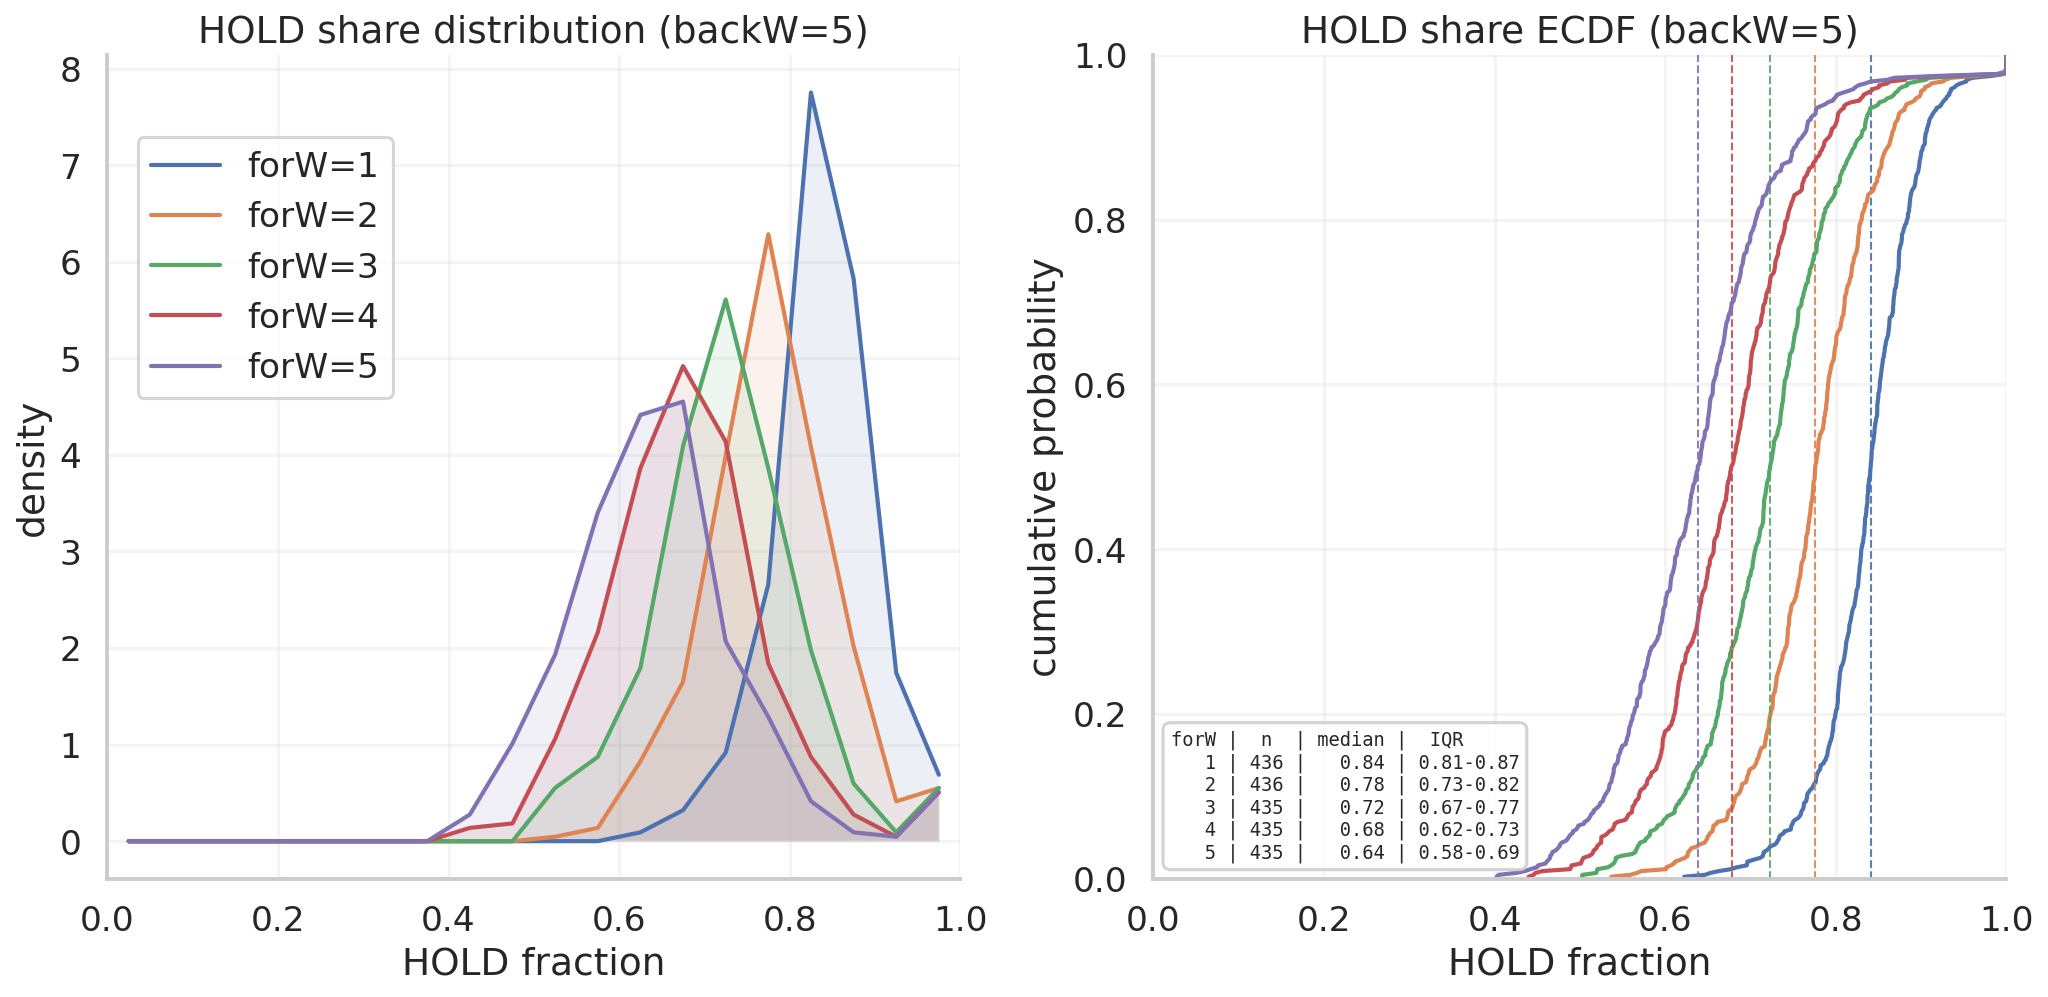

In [11]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)

# 1) wybór forW: unikalnie + tylko dostępne + posortowane
compare_forW = [1, DEFAULT_FORW, 3, 4, 5]
compare_forW = sorted({w for w in compare_forW if w in forW_values})

if len(compare_forW) < 2:
    raise ValueError("Need at least 2 forW values available for HOLD comparison.")

# 2) zbierz dane + policz statystyki
hold_sources = {}
stats = []  # (forW, n, median, q25, q75)
for forW in compare_forW:
    series = (
        report_df[(report_df["backW"] == DEFAULT_BACKW) & (report_df["forW"] == forW)]["share_hold"]
        .dropna()
        .astype(float)
    )
    if series.empty:
        raise ValueError(f"No HOLD share values for backW={DEFAULT_BACKW}, forW={forW}.")
    hold_sources[forW] = series.values

    q25, med, q75 = np.quantile(series.values, [0.25, 0.5, 0.75])
    stats.append((forW, len(series), med, q25, q75))

# 3) wspólne biny + spójna skala
bins = np.linspace(0, 1, 21)  # co 0.05
centers = 0.5 * (bins[:-1] + bins[1:])

# ---- PANEL A: histogramy jako DENSITY (porównywalność) ----
ax = axes[0]
for forW in compare_forW:
    x = hold_sources[forW]
    counts, _ = np.histogram(x, bins=bins, density=True)
    ax.plot(centers, counts, lw=2, label=f"forW={forW}")
    ax.fill_between(centers, counts, alpha=0.10)

ax.set_title(f"HOLD share distribution (backW={DEFAULT_BACKW})")
ax.set_xlabel("HOLD fraction")
ax.set_ylabel("density")
ax.set_xlim(0, 1)
ax.grid(True, alpha=0.2)

# ---- PANEL B: ECDF + median lines + stat box ----
ax = axes[1]
for forW in compare_forW:
    x = np.sort(hold_sources[forW])
    y = np.arange(1, len(x) + 1) / len(x)
    line = ax.plot(x, y, lw=2, label=f"forW={forW}")[0]

    # median line (ten sam kolor co ECDF)
    med = np.median(x)
    ax.axvline(med, color=line.get_color(), ls="--", lw=1, alpha=0.9)

ax.set_title(f"HOLD share ECDF (backW={DEFAULT_BACKW})")
ax.set_xlabel("HOLD fraction")
ax.set_ylabel("cumulative probability")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.2)

# stat box w rogu
lines = ["forW |  n  | median |  IQR"]
for (forW, n, med, q25, q75) in stats:
    lines.append(f"{forW:>4} | {n:>3} | {med:>6.2f} | {q25:>4.2f}-{q75:>4.2f}")
ax.text(
    0.02, 0.02,
    "\n".join(lines),
    transform=ax.transAxes,
    va="bottom",
    ha="left",
    fontsize=9,
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85, edgecolor="0.8"),
)

# legenda wspólna poza osiami
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", borderaxespad=4)

savefig(fig, "hold_share_hist.png")

Saved /home/kamil/binance-bot/data/charts_stage2/hold_share_by_symbol.png


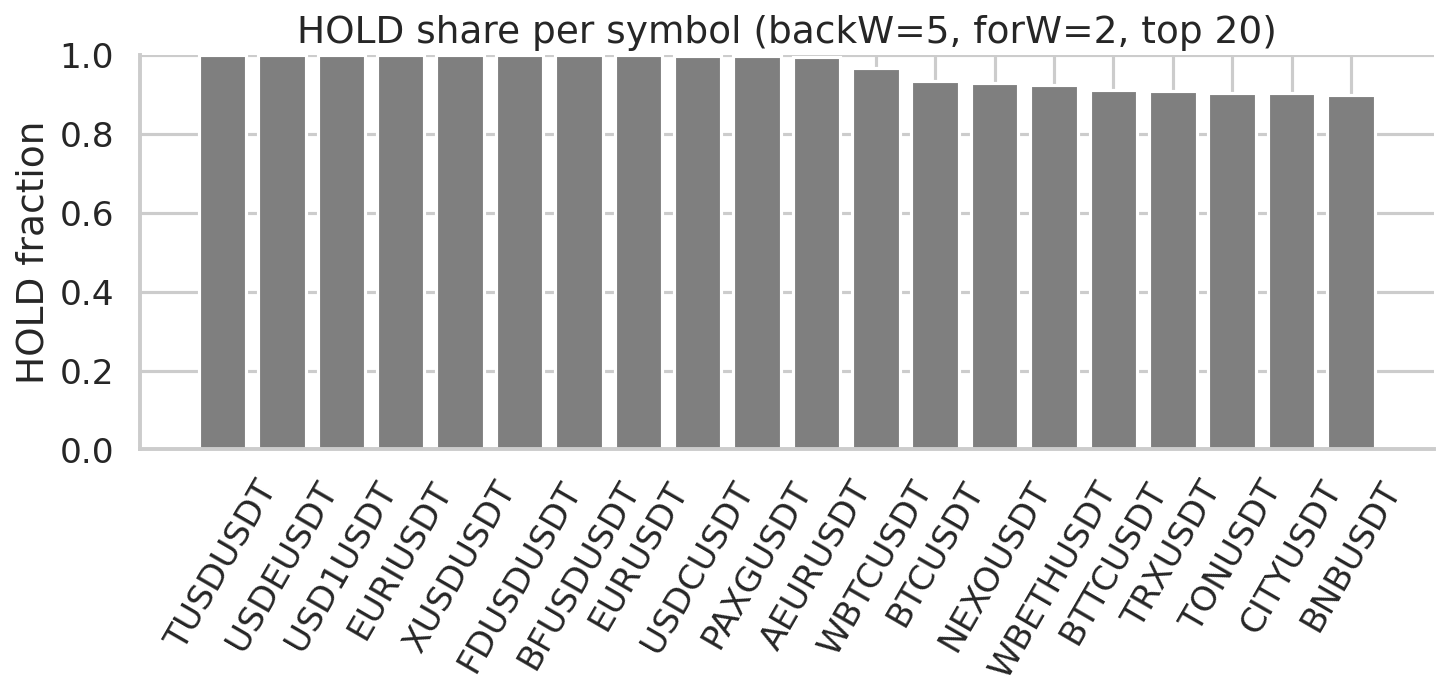

In [12]:
TOP_SYMBOLS = 20

window_symbol_df = report_df[(report_df["backW"] == DEFAULT_BACKW) & (report_df["forW"] == DEFAULT_FORW)]
if window_symbol_df.empty:
    raise ValueError(f"No reports found for backW={DEFAULT_BACKW} and forW={DEFAULT_FORW}.")

by_symbol = window_symbol_df.sort_values("share_hold", ascending=False).head(TOP_SYMBOLS)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(by_symbol["symbol"], by_symbol["share_hold"], color="tab:gray")
ax.set_title(f"HOLD share per symbol (backW={DEFAULT_BACKW}, forW={DEFAULT_FORW}, top {TOP_SYMBOLS})")
ax.set_ylabel("HOLD fraction")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=60)
savefig(fig, "hold_share_by_symbol.png")


## HOLD share by window
How HOLD dominance shifts across backW and forW choices.


Saved /home/kamil/binance-bot/data/charts_stage2/hold_share_by_window_violin.png


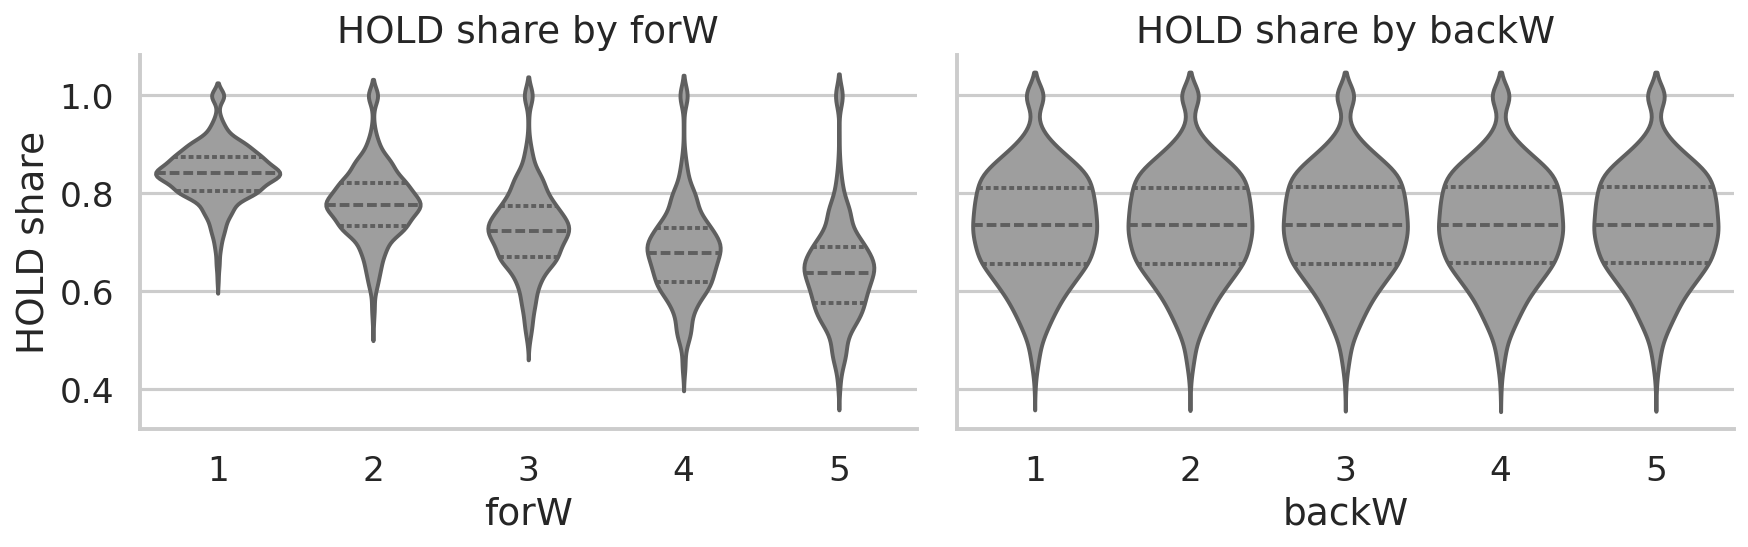

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.violinplot(data=report_df, x="forW", y="share_hold", ax=axes[0], color="#9e9e9e", inner="quartile")
axes[0].set_title("HOLD share by forW")
axes[0].set_xlabel("forW")
axes[0].set_ylabel("HOLD share")

sns.violinplot(data=report_df, x="backW", y="share_hold", ax=axes[1], color="#9e9e9e", inner="quartile")
axes[1].set_title("HOLD share by backW")
axes[1].set_xlabel("backW")
axes[1].set_ylabel("")

savefig(fig, "hold_share_by_window_violin.png")


## Label heatmaps (BUY / HOLD / SELL)
Mirrors `baseline_label_heatmaps.png` from Stage 1 notebooks.


Saved /home/kamil/binance-bot/data/charts_stage2/baseline_label_heatmaps.png


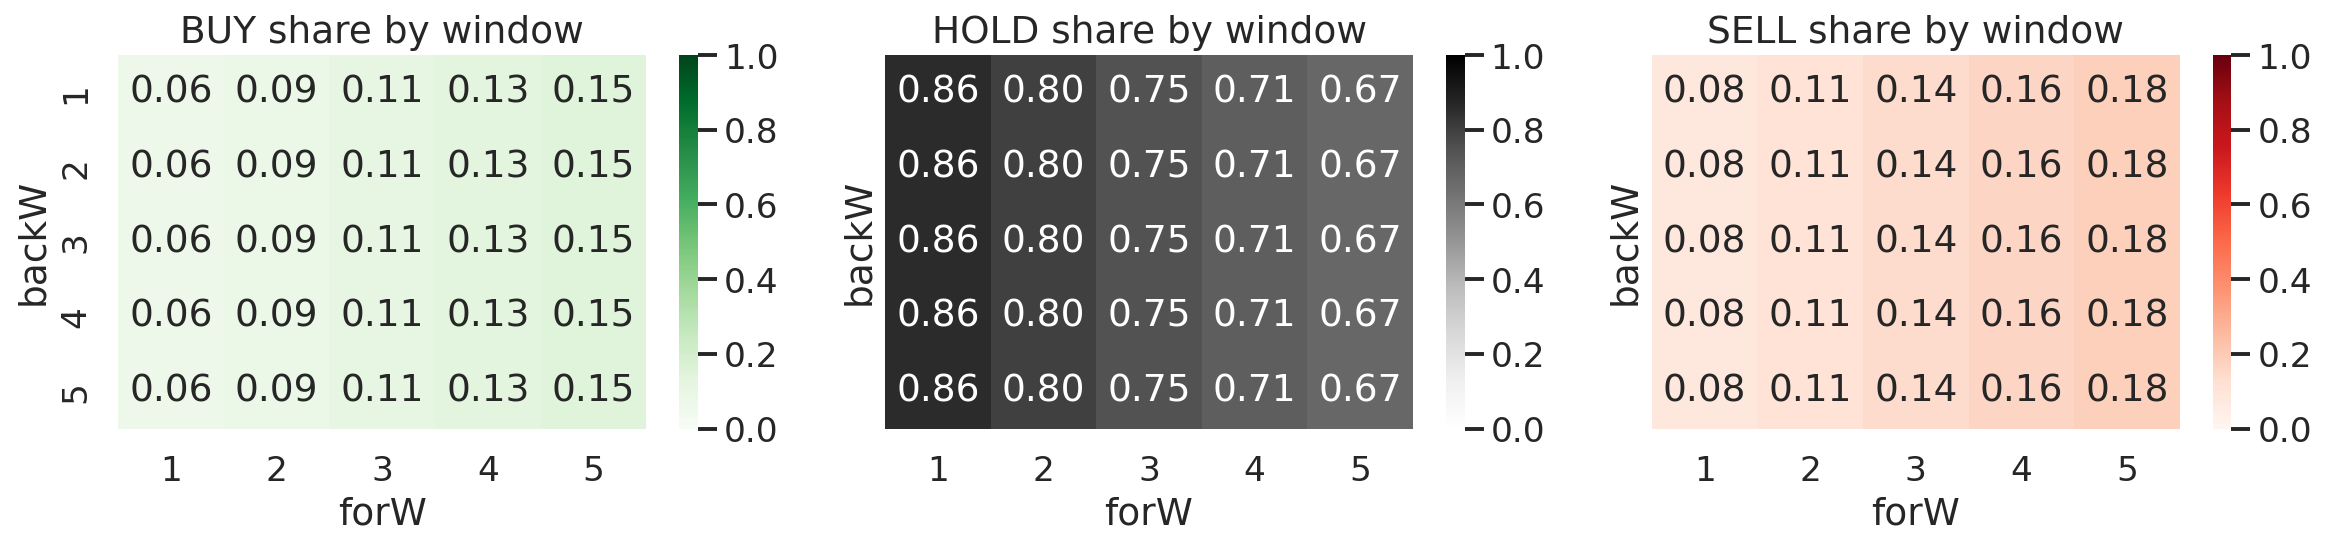

In [14]:
agg = report_df.groupby(["backW", "forW"])[["buy", "hold", "sell"]].sum().reset_index()
agg["total"] = agg[["buy", "hold", "sell"]].sum(axis=1)
for label in ["buy", "hold", "sell"]:
    agg[f"share_{label}"] = np.where(agg["total"] > 0, agg[label] / agg["total"], 0.0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (col, title, cmap) in zip(
    axes,
    [("share_buy", "BUY share by window", "Greens"), ("share_hold", "HOLD share by window", "Greys"), ("share_sell", "SELL share by window", "Reds")],
):
    pivot = agg.pivot(index="backW", columns="forW", values=col)
    sns.heatmap(pivot, vmin=0, vmax=1, cmap=cmap, annot=True, fmt=".2f", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("forW")
    ax.set_ylabel("backW")

savefig(fig, "baseline_label_heatmaps.png")


## Label mix by symbol
Top symbols by total labeled rows.


Saved /home/kamil/binance-bot/data/charts_stage2/label_mix_top_symbols.png


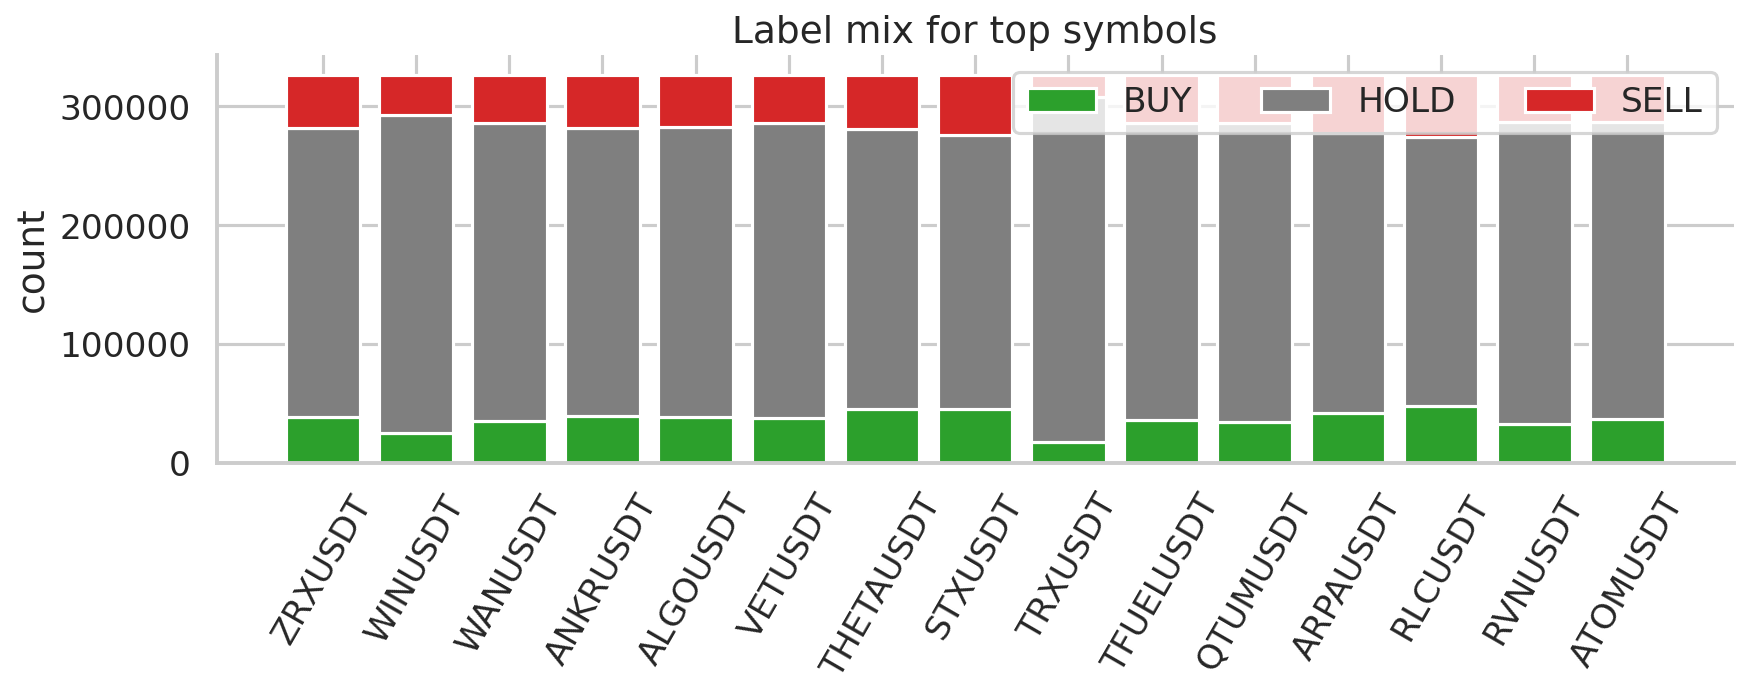

In [15]:
by_symbol_counts = report_df.groupby("symbol")[["buy", "hold", "sell"]].sum()
by_symbol_counts["total"] = by_symbol_counts.sum(axis=1)
top_symbols = by_symbol_counts.sort_values("total", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(top_symbols))
colors = {"buy": "#2ca02c", "hold": "#7f7f7f", "sell": "#d62728"}
for key, label in [("buy", "BUY"), ("hold", "HOLD"), ("sell", "SELL")]:
    values = top_symbols[key].values
    ax.bar(top_symbols.index, values, bottom=bottom, label=label, color=colors[key])
    bottom += values

ax.set_title("Label mix for top symbols")
ax.set_ylabel("count")
ax.tick_params(axis="x", rotation=60)
ax.legend(ncol=3, loc="upper right")
savefig(fig, "label_mix_top_symbols.png")


## Alpha/Beta sensitivity
Percentile sensitivity from pooled forward returns using backW=5 window timestamps.


In [16]:
# pick the symbol(s) for forward-return sampling
PREFERRED_SYMBOLS = ["ETHUSDT", "BTCUSDT"]

available_symbols = [s for s in PREFERRED_SYMBOLS if s in set(report_df["symbol"])]
if not available_symbols:
    available_symbols = (
        report_df.sort_values("n_valid", ascending=False)["symbol"].unique().tolist()[:2]
    )

sample_symbols = []
price_dfs = {}
sample_rows = {}

for symbol in available_symbols:
    processed_path = PROCESSED_DIR / f"{symbol}_{interval_safe}.parquet"
    if not processed_path.exists():
        print(f"Missing processed parquet for {symbol}: {processed_path}")
        continue
    df = pd.read_parquet(processed_path)
    df.index = pd.to_datetime(df.index, utc=True)
    price_dfs[symbol] = df.sort_index()
    row = report_df[report_df["symbol"] == symbol].sort_values("n_valid", ascending=False).iloc[0]
    sample_rows[symbol] = row
    sample_symbols.append(symbol)

if not sample_symbols:
    sample_row = report_df.sort_values("n_valid", ascending=False).iloc[0]
    sample_symbol = sample_row["symbol"]
    processed_path = PROCESSED_DIR / f"{sample_symbol}_{interval_safe}.parquet"
    if not processed_path.exists():
        raise FileNotFoundError(f"Missing processed parquet: {processed_path}")
    price_df = pd.read_parquet(processed_path)
    price_df.index = pd.to_datetime(price_df.index, utc=True)
    price_df = price_df.sort_index()
    price_dfs = {sample_symbol: price_df}
    sample_rows = {sample_symbol: sample_row}
    sample_symbols = [sample_symbol]

sample_symbol = sample_symbols[0]
sample_row = sample_rows[sample_symbol]
price_df = price_dfs[sample_symbol]

print(f"Using sample symbols: {sample_symbols}")


def forward_returns(df: pd.DataFrame, forW: int, fee: float) -> pd.Series:
    close_fwd = df["close"].shift(-forW)
    return ((1.0 - fee) * close_fwd - (1.0 + fee) * df["open"]) / df["open"]


# pooled returns across symbols for each forW (from dataset timestamps, backW default)
MAX_PROCESSED_FOR_RETURNS = None  # set to an int to limit processing
RETURN_SAMPLE_MAX = 200_000

pattern = re.compile(rf"(.+?)_{re.escape(interval_safe)}_backW(\d+)_forW(\d+)$")
dataset_paths = sorted(DATASETS_DIR.glob(f"*_{interval_safe}_backW{DEFAULT_BACKW}_forW*.parquet"))
if MAX_PROCESSED_FOR_RETURNS:
    dataset_paths = dataset_paths[:MAX_PROCESSED_FOR_RETURNS]
if not dataset_paths:
    raise FileNotFoundError(f"No dataset parquet files found for backW={DEFAULT_BACKW} in {DATASETS_DIR}")

processed_cache = {}
returns_cache = {}
pooled_by_forW = {forW: [] for forW in forW_values}

iter_paths = dataset_paths
if HAS_IPY:
    iter_paths = tqdm(iter_paths, total=len(dataset_paths), desc=f"Collecting forward returns (backW={DEFAULT_BACKW})")

for path in iter_paths:
    match = pattern.match(path.stem)
    if not match:
        continue
    symbol, backW_str, forW_str = match.groups()
    forW = int(forW_str)
    if forW not in forW_values:
        continue

    ds = pd.read_parquet(path, columns=["ts"])
    ts = pd.to_datetime(ds["ts"], utc=True)
    if ts.empty:
        continue

    if symbol not in processed_cache:
        processed_path = PROCESSED_DIR / f"{symbol}_{interval_safe}.parquet"
        if not processed_path.exists():
            continue
        df = pd.read_parquet(processed_path, columns=["open", "close"])
        df.index = pd.to_datetime(df.index, utc=True)
        df = df.sort_index()
        processed_cache[symbol] = df
        returns_cache[symbol] = {}

    if forW not in returns_cache[symbol]:
        returns_cache[symbol][forW] = forward_returns(processed_cache[symbol], forW, fee)

    series = returns_cache[symbol][forW]
    aligned = series.reindex(ts).dropna()
    if not aligned.empty:
        pooled_by_forW[forW].append(aligned)

pooled_returns_by_forW = {
    forW: (pd.concat(chunks, ignore_index=True) if chunks else pd.Series(dtype="float64"))
    for forW, chunks in pooled_by_forW.items()
}
pooled_abs_by_forW = {forW: series.abs() for forW, series in pooled_returns_by_forW.items()}

VISUAL_FORW = DEFAULT_FORW if DEFAULT_FORW in forW_values else (min(forW_values) if forW_values else 1)
pooled_signed_returns = pooled_returns_by_forW.get(VISUAL_FORW, pd.Series(dtype="float64"))
pooled_abs_returns = pooled_abs_by_forW.get(VISUAL_FORW, pd.Series(dtype="float64"))
plot_returns_by_forW = {forW: sample_series(series, RETURN_SAMPLE_MAX) for forW, series in pooled_returns_by_forW.items()}

if pooled_abs_returns.empty:
    raise ValueError("No forward returns available for sampling.")


Using sample symbols: ['ETHUSDT', 'BTCUSDT']


## Forward return distributions
Compare forW=2 vs forW=4 (backW=5), with dynamic x-limits from the 99.5% quantile.


Saved /home/kamil/binance-bot/data/charts_stage2/forward_return_distributions_wrong.png


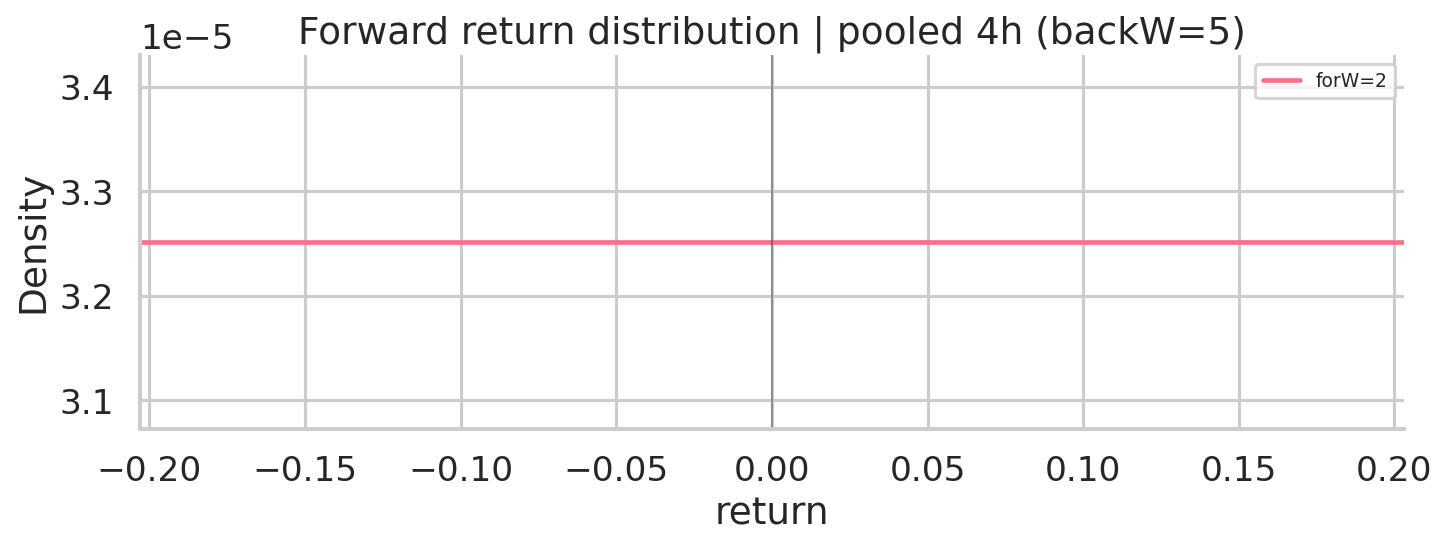

In [17]:
compare_forW = [DEFAULT_FORW]
compare_forW = [w for w in compare_forW if w in forW_values]
# if len(compare_forW) < 2:
#     raise ValueError("Need forW=2 and forW=4 (or available defaults) for return distribution comparison.")

fig, ax = plt.subplots(figsize=(10, 4))

palette = sns.color_palette("husl", n_colors=len(compare_forW))
combined = []
for color, forW in zip(palette, compare_forW):
    series = plot_returns_by_forW.get(forW)
    if series is None or series.empty:
        continue
    combined.append(series)
    sns.histplot(
        series,
        bins=1,
        stat="density",
        element="step",
        fill=False,
        ax=ax,
        color=color,
        label=f"forW={forW}",
    )

if combined:
    limit = float(pd.concat(combined).abs().quantile(0.995))
    ax.set_xlim(-limit, limit)

ax.axvline(0, color="black", alpha=0.3, lw=1)
ax.set_title(f"Forward return distribution | pooled {interval} (backW={DEFAULT_BACKW})")
ax.set_xlabel("return")
ax.legend(ncol=2, fontsize=9)

savefig(fig, "forward_return_distributions_wrong.png")


forW=2: n=200000, nunique=182163, zeros=0.00%
forW=3: n=200000, nunique=183741, zeros=0.00%


/tmp/ipykernel_3869/1067495984.py:46: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/tmp/ipykernel_3869/1067495984.py:47: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(path, dpi=150, bbox_inches="tight")


Saved /home/kamil/binance-bot/data/charts_stage2/forward_return_distributions.png


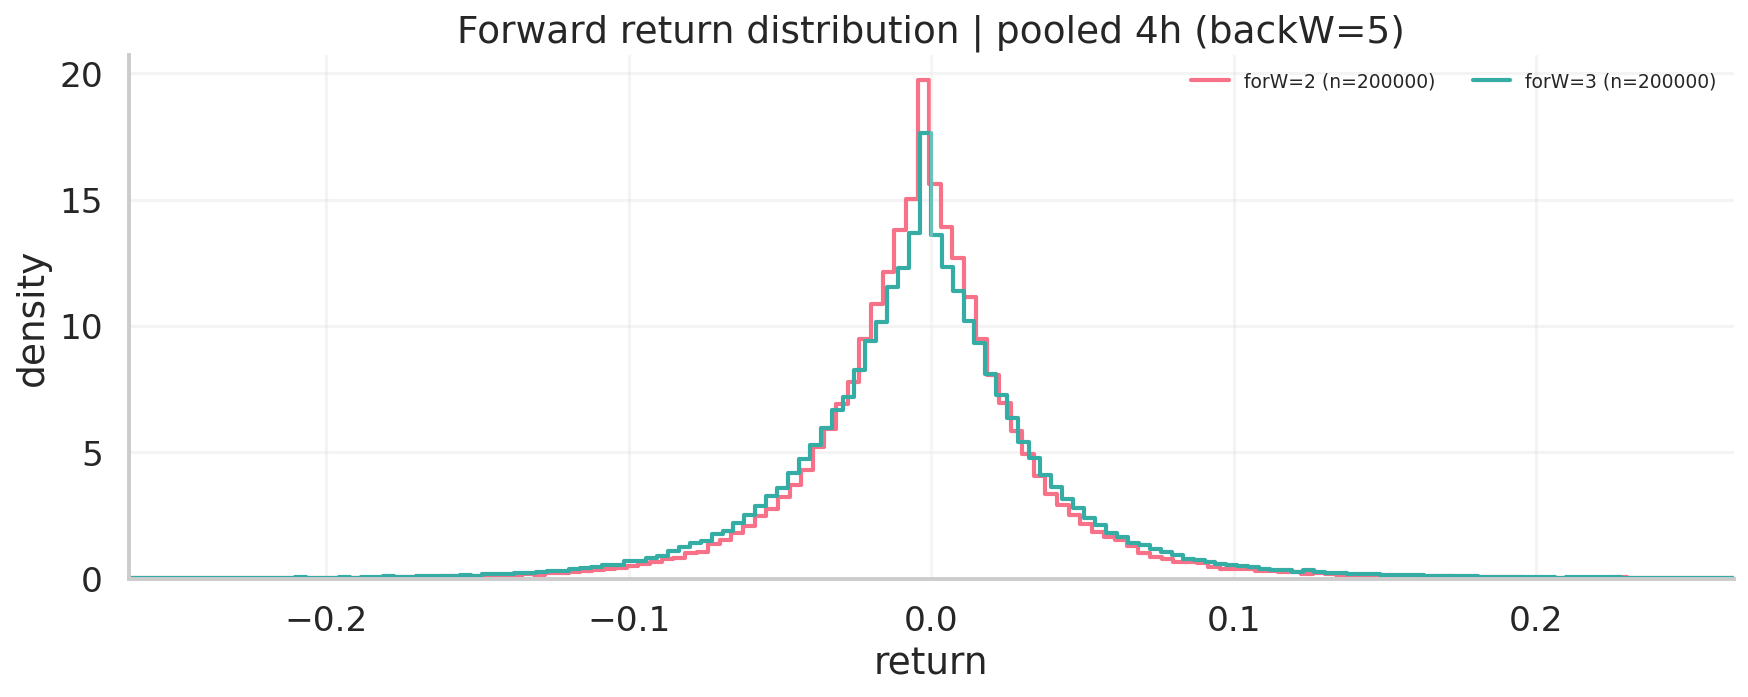

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

compare_forW = [DEFAULT_FORW,3]
compare_forW = [w for w in compare_forW if w in forW_values]

fig, ax = plt.subplots(figsize=(12, 5))

series_list = []
for forW in compare_forW:
    s = plot_returns_by_forW.get(forW)
    if s is None:
        raise ValueError(f"plot_returns_by_forW has no key for forW={forW}. Available: {sorted(plot_returns_by_forW.keys())}")
    s = s.replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    if s.empty:
        raise ValueError(f"Return series for forW={forW} is empty after cleaning.")
    series_list.append((forW, s))

# debug info (polecam zostawić na chwilę)
for forW, s in series_list:
    print(f"forW={forW}: n={len(s)}, nunique={s.nunique()}, zeros={(s==0).mean():.2%}")

palette = sns.color_palette("husl", n_colors=len(series_list))
combined = []

for (forW, s), color in zip(series_list, palette):
    combined.append(s)
    sns.histplot(
        s,
        bins=8_000_000,                 # 14 to często za mało
        stat="density",
        element="step",
        fill=False,
        ax=ax,
        color=color,
        linewidth=2,
        label=f"forW={forW} (n={len(s)})",
    )

limit = float(pd.concat(combined).abs().quantile(0.997))
ax.set_xlim(-limit, limit)

ax.axvline(0, color="white", alpha=0.25, lw=1.5)
ax.set_title(f"Forward return distribution | pooled {interval} (backW={DEFAULT_BACKW})")
ax.set_xlabel("return")
ax.set_ylabel("density")
ax.grid(True, alpha=0.2)
ax.legend(ncol=2, fontsize=9, frameon=False)

savefig(fig, "forward_return_distributions.png")

Saved /home/kamil/binance-bot/data/charts_stage2/forward_return_kde_all_forW_log.png


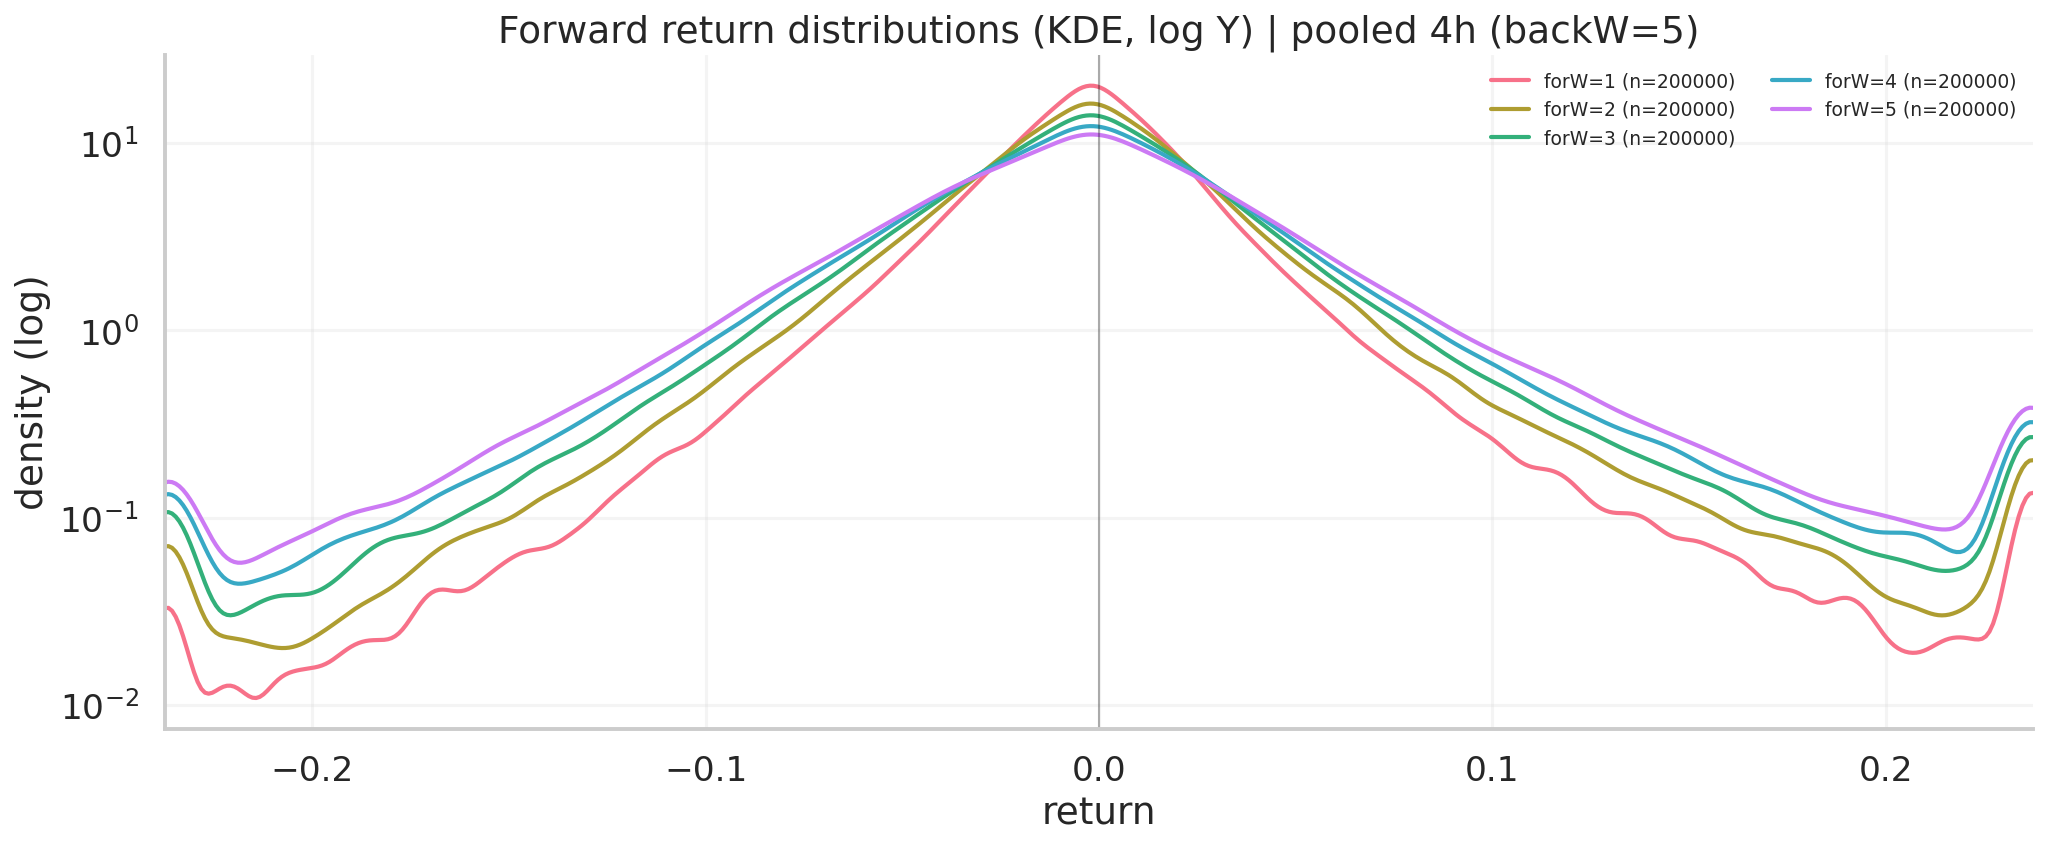

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

# przygotuj serie
series_by_forW = {}
for forW in sorted(forW_values):
    s = plot_returns_by_forW.get(forW)
    if s is None:
        continue
    s = s.replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    if not s.empty:
        series_by_forW[forW] = s

all_series = pd.concat(series_by_forW.values())
limit = float(all_series.abs().quantile(0.995))
if limit <= 0:
    limit = float(all_series.abs().max() or 1e-6)

palette = sns.color_palette("husl", n_colors=len(series_by_forW))

for color, (forW, s) in zip(palette, series_by_forW.items()):
    s = s.clip(-limit, limit)
    sns.kdeplot(
        s,
        ax=ax,
        color=color,
        lw=2,
        label=f"forW={forW} (n={len(s)})",
        bw_adjust=1.4,     # <-- zwiększ dla większego wygładzenia (np. 2.0)
        cut=0,             # nie wychodź poza zakres danych
        clip=(-limit, limit),
        gridsize=512
    )

ax.set_xlim(-limit, limit)
ax.axvline(0, color="black", alpha=0.3, lw=1)
ax.set_title(f"Forward return distributions (KDE, log Y) | pooled {interval} (backW={DEFAULT_BACKW})")
ax.set_xlabel("return")
ax.set_ylabel("density (log)")
ax.set_yscale("log")
ax.grid(True, alpha=0.2)
ax.legend(frameon=False, ncol=2, fontsize=9)

savefig(fig, "forward_return_kde_all_forW_log.png")

## Tail risk curve
Percentile curve of |forward returns| with alpha/beta markers from config percentiles.


In [21]:
pooled_returns_by_forW = {
    forW: (pd.concat(chunks, ignore_index=True) if chunks else pd.Series(dtype="float64"))
    for forW, chunks in pooled_by_forW.items()
}
pooled_abs_by_forW = {forW: series.abs() for forW, series in pooled_returns_by_forW.items()}

VISUAL_FORW = DEFAULT_FORW if DEFAULT_FORW in forW_values else (min(forW_values) if forW_values else 1)
pooled_signed_returns = pooled_returns_by_forW.get(VISUAL_FORW, pd.Series(dtype="float64"))
pooled_abs_returns = pooled_abs_by_forW.get(VISUAL_FORW, pd.Series(dtype="float64"))
plot_returns_by_forW = {forW: sample_series(series, RETURN_SAMPLE_MAX) for forW, series in pooled_returns_by_forW.items()}

if pooled_abs_returns.empty:
    raise ValueError("No forward returns available for sampling.")

alpha_pct_cfg = float(single_pct.get("alpha_pct", 0.25))
beta_pct_cfg = float(single_pct.get("beta_pct", 0.997))

pct_min = min(0.5, alpha_pct_cfg, beta_pct_cfg)
percentiles = np.linspace(pct_min, 0.999, 80)
alpha_vals = pooled_abs_returns.quantile(percentiles)
beta_vals = pooled_abs_returns.quantile(percentiles)
alpha_val = float(pooled_abs_returns.quantile(alpha_pct_cfg))
beta_val = float(pooled_abs_returns.quantile(beta_pct_cfg))

alpha_used = alpha_val
beta_used = beta_val
alpha_used_pct = alpha_pct_cfg
beta_used_pct = beta_pct_cfg

Saved /home/kamil/binance-bot/data/charts_stage2/tail_curve_abs_returns.png


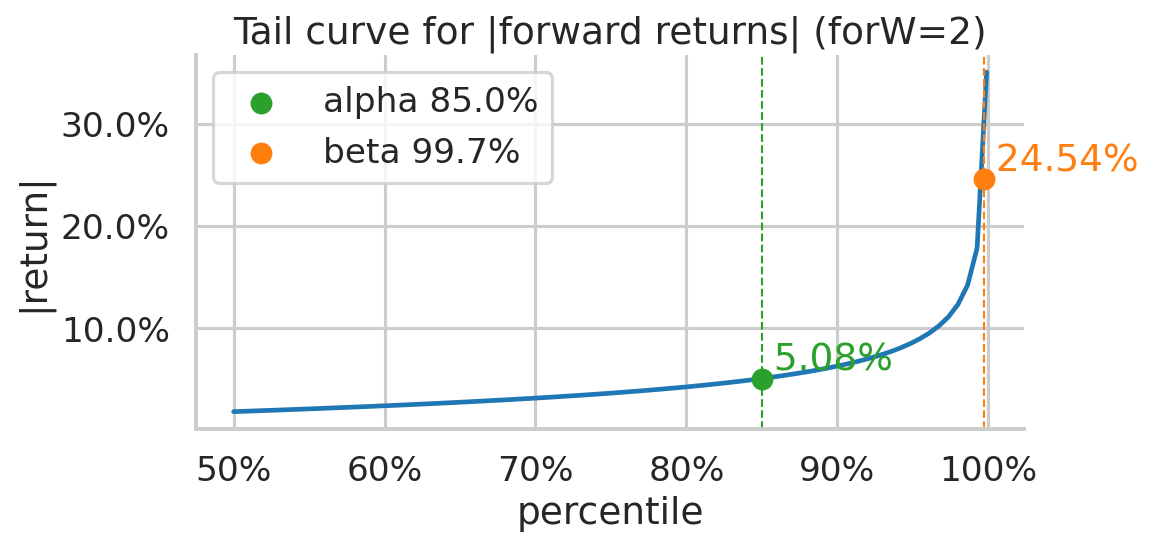

In [22]:
tail_curve = pooled_abs_returns.quantile(percentiles)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tail_curve.index, tail_curve.values, color="tab:blue")
ax.scatter([alpha_pct_cfg], [alpha_val], color="tab:green", zorder=3, label=f"alpha {alpha_pct_cfg:.1%}")
ax.axvline(alpha_pct_cfg, color="tab:green", linestyle="--", linewidth=1)
ax.scatter([beta_pct_cfg], [beta_val], color="tab:orange", zorder=3, label=f"beta {beta_pct_cfg:.1%}")
ax.axvline(beta_pct_cfg, color="tab:orange", linestyle="--", linewidth=1)
ax.text(alpha_pct_cfg, alpha_val, f" {alpha_val:.2%}", color="tab:green", va="bottom")
ax.text(beta_pct_cfg, beta_val, f" {beta_val:.2%}", color="tab:orange", va="bottom")
ax.set_title(f"Tail curve for |forward returns| (forW={VISUAL_FORW})")
ax.set_xlabel("percentile")
ax.set_ylabel("|return|")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()

savefig(fig, "tail_curve_abs_returns.png")


## Video-ready visuals (dark mode)
Stylized charts tuned for presentations and video.


Saved /home/kamil/binance-bot/data/charts_stage2/visual_1_distribution.png


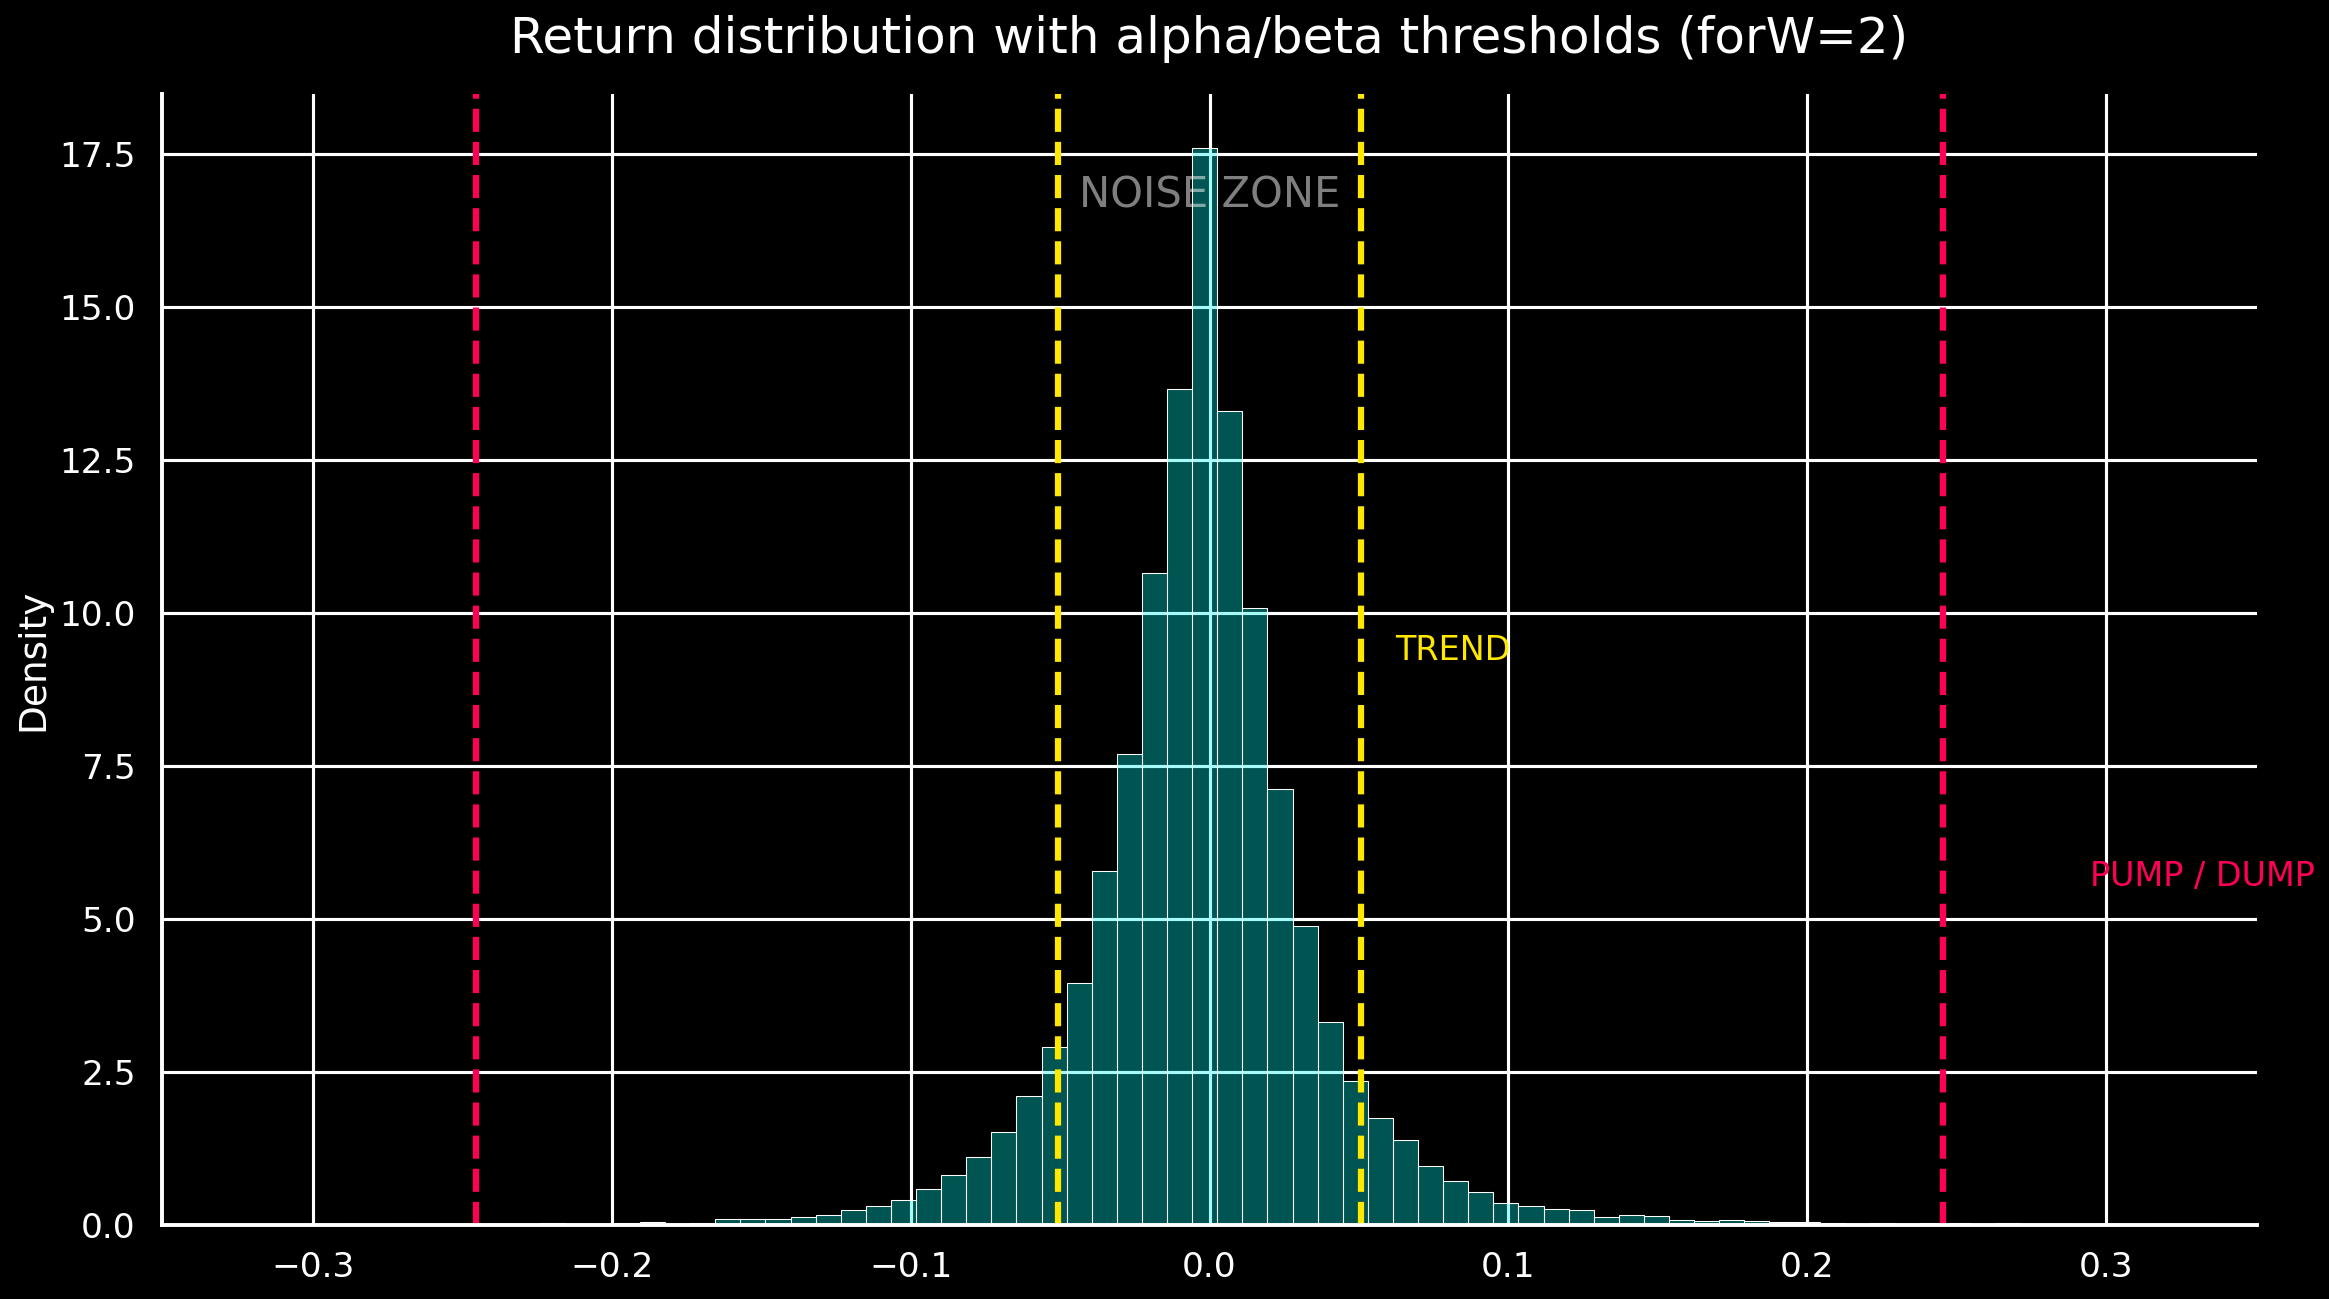

In [ ]:
# --- Visual 1: Return distribution + thresholds ---
with plt.style.context("dark_background"):
    sns.set_context("talk")
    fig, ax = plt.subplots(figsize=(16, 9))
    plot_signed = sample_series(pooled_signed_returns, 40000)
    sns.histplot(plot_signed, bins=160, stat="density", color="#00f2ea", alpha=0.35, ax=ax)

    ax.axvline(alpha_used, color="#ffe700", ls="--", lw=3, label=f"Alpha used ({alpha_used:.2%})")
    ax.axvline(-alpha_used, color="#ffe700", ls="--", lw=3)
    ax.axvline(beta_used, color="#ff0055", ls="--", lw=3, label=f"Beta used ({beta_used:.2%})")
    ax.axvline(-beta_used, color="#ff0055", ls="--", lw=3)

    ylim = ax.get_ylim()
    ax.text(0, ylim[1] * 0.9, "NOISE ZONE", color="white", ha="center", fontsize=20, alpha=0.5)
    ax.text(alpha_used * 1.6, ylim[1] * 0.5, "TREND", color="#ffe700", fontsize=16, ha="center")
    ax.text(beta_used * 1.2, ylim[1] * 0.3, "PUMP / DUMP", color="#ff0055", fontsize=16, ha="left")

    limit = float(pooled_signed_returns.abs().quantile(0.999))
    ax.set_xlim(-limit, limit)
    ax.set_title(f"Return distribution with alpha/beta thresholds (forW={VISUAL_FORW})", fontsize=24, pad=20)
    window_rows = (
        window_alpha_beta.sort_values(["backW", "forW"])
        if "window_alpha_beta" in globals()
        else report_df.groupby(["backW", "forW"])[["alpha", "beta"]].median().reset_index()
    )
    lines = []
    for backW in sorted(window_rows["backW"].unique()):
        subset = window_rows[window_rows["backW"] == backW].sort_values("forW")
        parts = [
            f"f{int(row.forW)} a={row.alpha:.2%} b={row.beta:.2%}"
            for row in subset.itertuples(index=False)
        ]
        lines.append(f"b{int(backW)}: " + ", ".join(parts))
    alpha_beta_text = "\n".join(lines)

    savefig(fig, "visual_1_distribution.png")


/tmp/ipykernel_3869/1067495984.py:46: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


Saved /home/kamil/binance-bot/data/charts_stage2/visual_1_distribution_different.png


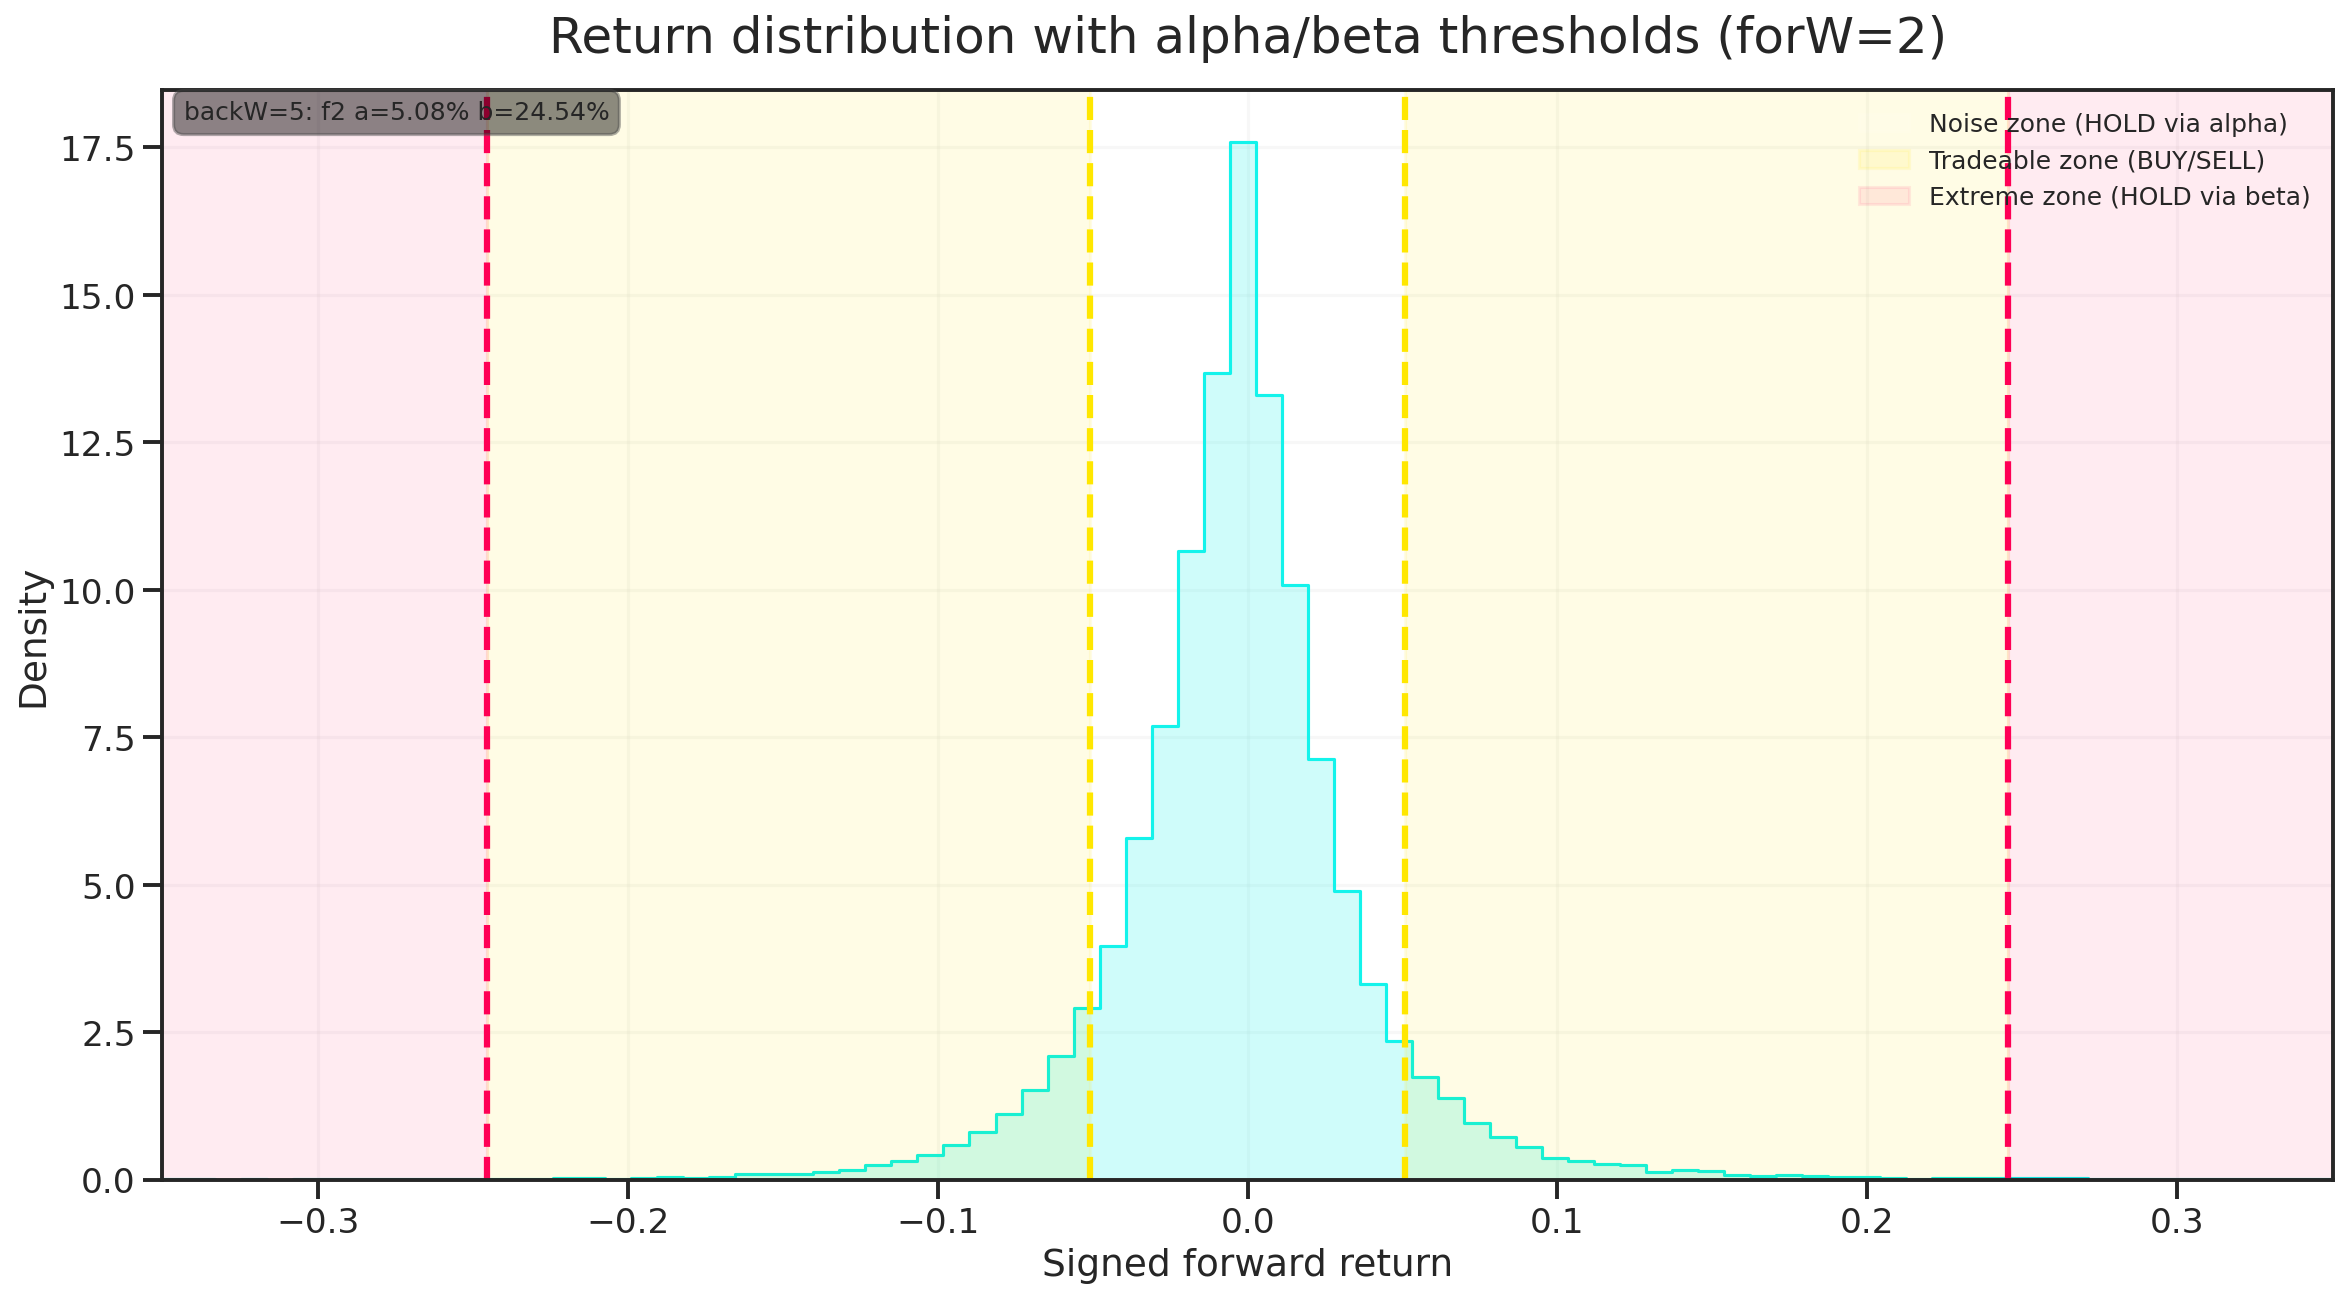

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visual 1: Return distribution + thresholds ---
with plt.style.context("dark_background"):
    sns.set_theme(context="talk", style="ticks")  # stabilniej niż set_context solo

    fig, ax = plt.subplots(figsize=(16, 9), constrained_layout=True)

    # 1) sanity: usuń NaN/inf
    s = pooled_signed_returns.copy()
    s = s.replace([np.inf, -np.inf], np.nan).dropna()

    # 2) próbkowanie bez niespodzianek
    plot_signed = sample_series(s, 40000)

    # 3) histogram (density) - czytelniej z element="step"
    sns.histplot(
        plot_signed,
        bins=160,
        stat="density",
        element="step",
        fill=True,
        color="#00f2ea",
        alpha=0.20,
        ax=ax
    )

    # 4) strefy (storytelling) — zamiast samych napisów
    # Noise: [-alpha, alpha]
    ax.axvspan(-alpha_used, alpha_used, color="white", alpha=0.08, label="Noise zone (HOLD via alpha)")

    # Trend-ish: (alpha..beta) i (-beta..-alpha)
    ax.axvspan(alpha_used, beta_used, color="#ffe700", alpha=0.10, label="Tradeable zone (BUY/SELL)")
    ax.axvspan(-beta_used, -alpha_used, color="#ffe700", alpha=0.10)

    # Extremes: beyond beta
    ax.axvspan(beta_used, s.abs().quantile(0.999), color="#ff0055", alpha=0.08, label="Extreme zone (HOLD via beta)")
    ax.axvspan(-s.abs().quantile(0.999), -beta_used, color="#ff0055", alpha=0.08)

    # 5) linie progów (zostaw, ale dopnij legendę)
    ax.axvline(alpha_used, color="#ffe700", ls="--", lw=3)
    ax.axvline(-alpha_used, color="#ffe700", ls="--", lw=3)
    ax.axvline(beta_used, color="#ff0055", ls="--", lw=3)
    ax.axvline(-beta_used, color="#ff0055", ls="--", lw=3)

    # 6) sensowny limit osi X (symetrycznie)
    limit = float(s.abs().quantile(0.999))
    if limit == 0:  # awaryjnie, gdyby były same zera
        limit = float(s.abs().max() or 1e-6)
    ax.set_xlim(-limit, limit)

    # 7) opisy osi + grid
    ax.set_xlabel("Signed forward return")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.15)

    # 8) tytuł
    ax.set_title(
        f"Return distribution with alpha/beta thresholds (forW={VISUAL_FORW})",
        fontsize=24,
        pad=18
    )

    # 9) jeśli chcesz wyświetlić alpha/beta per window — DOPIERO TUTAJ ma sens
    # 9) alpha/beta per window — ale spójne z alpha_used/beta_used
    window_rows = (
        window_alpha_beta.sort_values(["backW", "forW"])
        if "window_alpha_beta" in globals()
        else report_df.groupby(["backW", "forW"])[["alpha", "beta"]].median().reset_index()
    )

    # WYMUSZENIE spójności: w boxie pokazujemy dokładnie to, co rysujemy na wykresie
    window_rows = window_rows.copy()
    window_rows["alpha"] = float(alpha_used)
    window_rows["beta"]  = float(beta_used)

    backW_show = DEFAULT_BACKW if "DEFAULT_BACKW" in globals() else None
    if backW_show is not None and "backW" in window_rows.columns:
        subset = window_rows[(window_rows["backW"] == backW_show) & (window_rows["forW"] == VISUAL_FORW)]
        if not subset.empty:
            ax.text(
                0.01, 0.99, f"backW={int(backW_show)}: f{int(VISUAL_FORW)} a={alpha_used:.2%} b={beta_used:.2%}",
                transform=ax.transAxes,
                ha="left", va="top",
                fontsize=12,
                bbox=dict(boxstyle="round,pad=0.4", facecolor="black", alpha=0.45, edgecolor="0.3")
            )

    # 10) legenda (to Ci brakowało)
    ax.legend(loc="upper right", frameon=False, fontsize=12)

    savefig(fig, "visual_1_distribution_different.png")

In [26]:
print("alpha_used:", alpha_used, "->", f"{alpha_used:.2%}")
print("beta_used :", beta_used,  "->", f"{beta_used:.2%}")

print("alpha_val :", alpha_val,  "->", f"{alpha_val:.2%}")
print("beta_val  :", beta_val,   "->", f"{beta_val:.2%}")

print("abs pools same?", np.allclose(
    pooled_abs_returns.dropna().values,
    pooled_signed_returns.abs().dropna().values
))

alpha_used: 0.050786282054543705 -> 5.08%
beta_used : 0.24543698195436897 -> 24.54%
alpha_val : 0.050786282054543705 -> 5.08%
beta_val  : 0.24543698195436897 -> 24.54%
abs pools same? True


Saved /home/kamil/binance-bot/data/charts_stage2/visual_2_logic.png


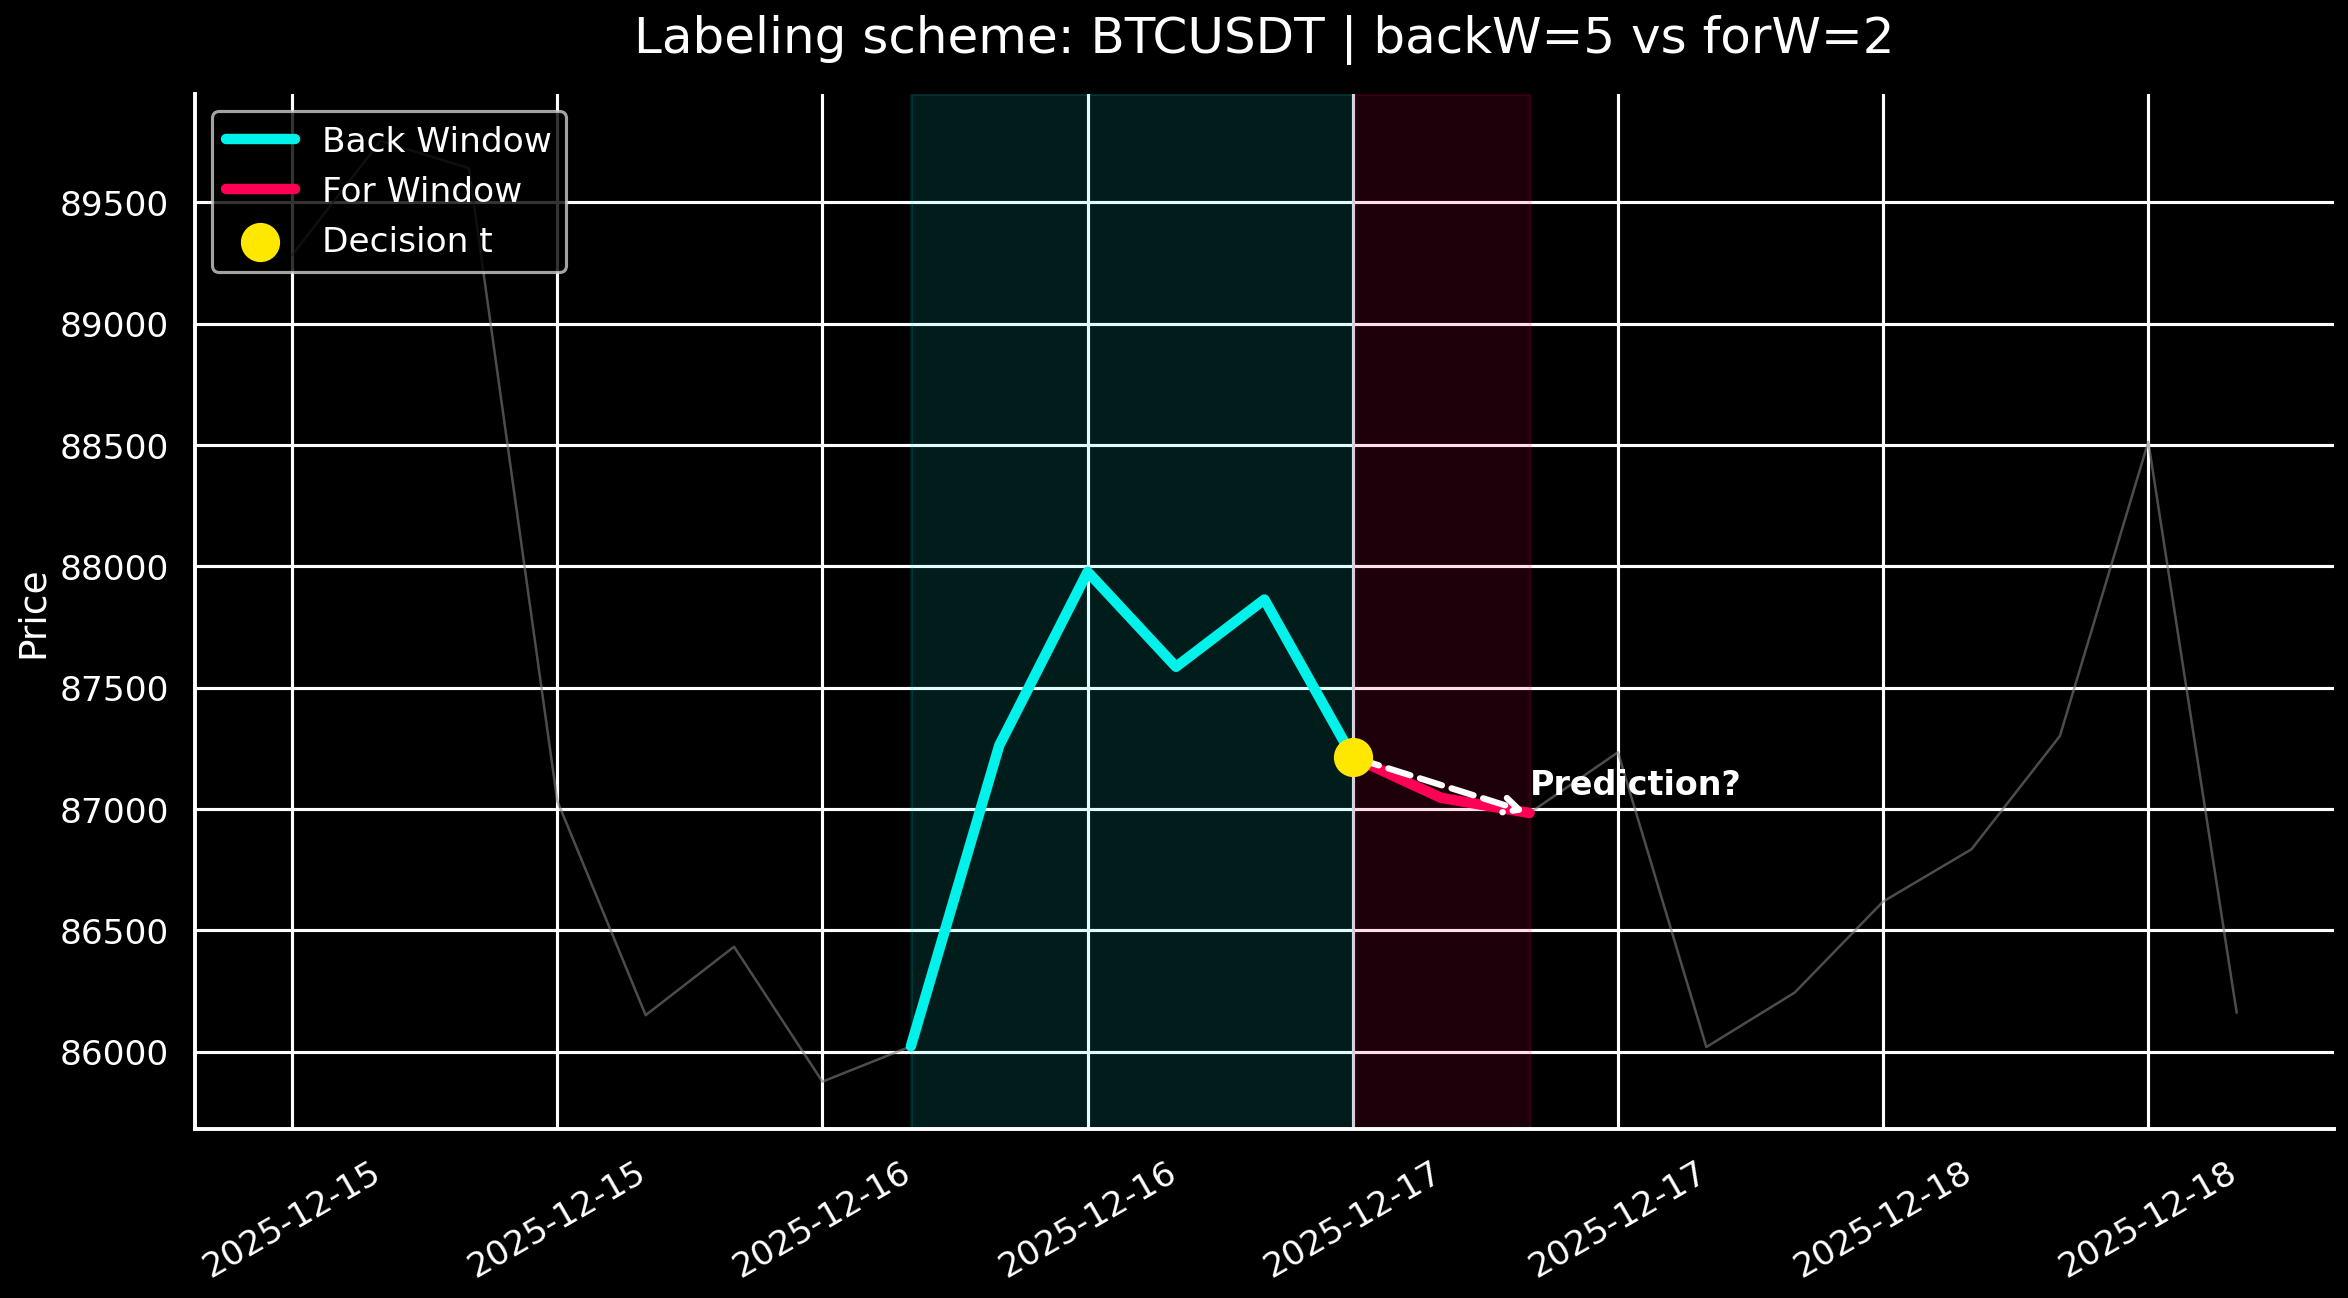

In [ ]:
# --- Visual 2: Labeling logic on real price ---
logic_symbol = "BTCUSDT" if "BTCUSDT" in sample_symbols else sample_symbols[0]
logic_df = price_dfs[logic_symbol].copy()

TARGET_BACKW = DEFAULT_BACKW
TARGET_FORW = DEFAULT_FORW
logic_window = report_df[
    (report_df["symbol"] == logic_symbol)
    & (report_df["backW"] == TARGET_BACKW)
    & (report_df["forW"] == TARGET_FORW)
]
if logic_window.empty:
    raise ValueError(f"Missing window backW={TARGET_BACKW}, forW={TARGET_FORW} for {logic_symbol}.")

back_w = TARGET_BACKW
for_w = TARGET_FORW

prices = logic_df["close"].dropna()
if len(prices) <= back_w + for_w + 5:
    raise ValueError("Not enough data for the labeling logic visual.")

buffer = max(8, back_w)
segment_len = min(len(prices), back_w + for_w + buffer * 2)
start = max(0, len(prices) - segment_len)
segment = prices.iloc[start : start + segment_len]

max_t_rel = len(segment) - for_w - 2
t_rel = min(buffer + back_w - 1, max_t_rel)
t_rel = max(t_rel, back_w)

back_slice = segment.iloc[t_rel - back_w : t_rel + 1]
forward_slice = segment.iloc[t_rel : t_rel + for_w + 1]

with plt.style.context("dark_background"):
    sns.set_context("talk")
    fig, ax = plt.subplots(figsize=(16, 9))
    ax.plot(segment.index, segment.values, color="gray", lw=1.2, alpha=0.6)

    ax.plot(back_slice.index, back_slice.values, color="#00f2ea", lw=5, label="Back Window")
    ax.plot(forward_slice.index, forward_slice.values, color="#ff0055", lw=5, label="For Window")
    ax.scatter(segment.index[t_rel], segment.iloc[t_rel], color="#ffe700", s=300, zorder=5, label="Decision t")

    ax.annotate(
        "",
        xy=(forward_slice.index[-1], forward_slice.iloc[-1]),
        xytext=(segment.index[t_rel], segment.iloc[t_rel]),
        arrowprops=dict(arrowstyle="->", color="white", lw=3, ls="dashed"),
    )
    ax.text(
        forward_slice.index[-1],
        (segment.iloc[t_rel] + forward_slice.iloc[-1]) / 2,
        "Prediction?",
        color="white",
        fontsize=16,
        fontweight="bold",
        ha="left",
        va="center",
    )

    ax.axvspan(back_slice.index[0], back_slice.index[-1], color="#00f2ea", alpha=0.12)
    ax.axvspan(forward_slice.index[0], forward_slice.index[-1], color="#ff0055", alpha=0.12)

    ax.set_title(
        f"Labeling scheme: {logic_symbol} | backW={back_w} vs forW={for_w}",
        fontsize=24,
        pad=20,
    )
    ax.set_ylabel("Price")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.tick_params(axis="x", rotation=30)
    ax.legend(loc="upper left")

    savefig(fig, "visual_2_logic.png")


## Recent candles with labels
Analog of `recent_candles.png` and `window_examples.png`: we overlay labels on the latest slice of price.


Saved /home/kamil/binance-bot/data/charts_stage2/recent_candles.png


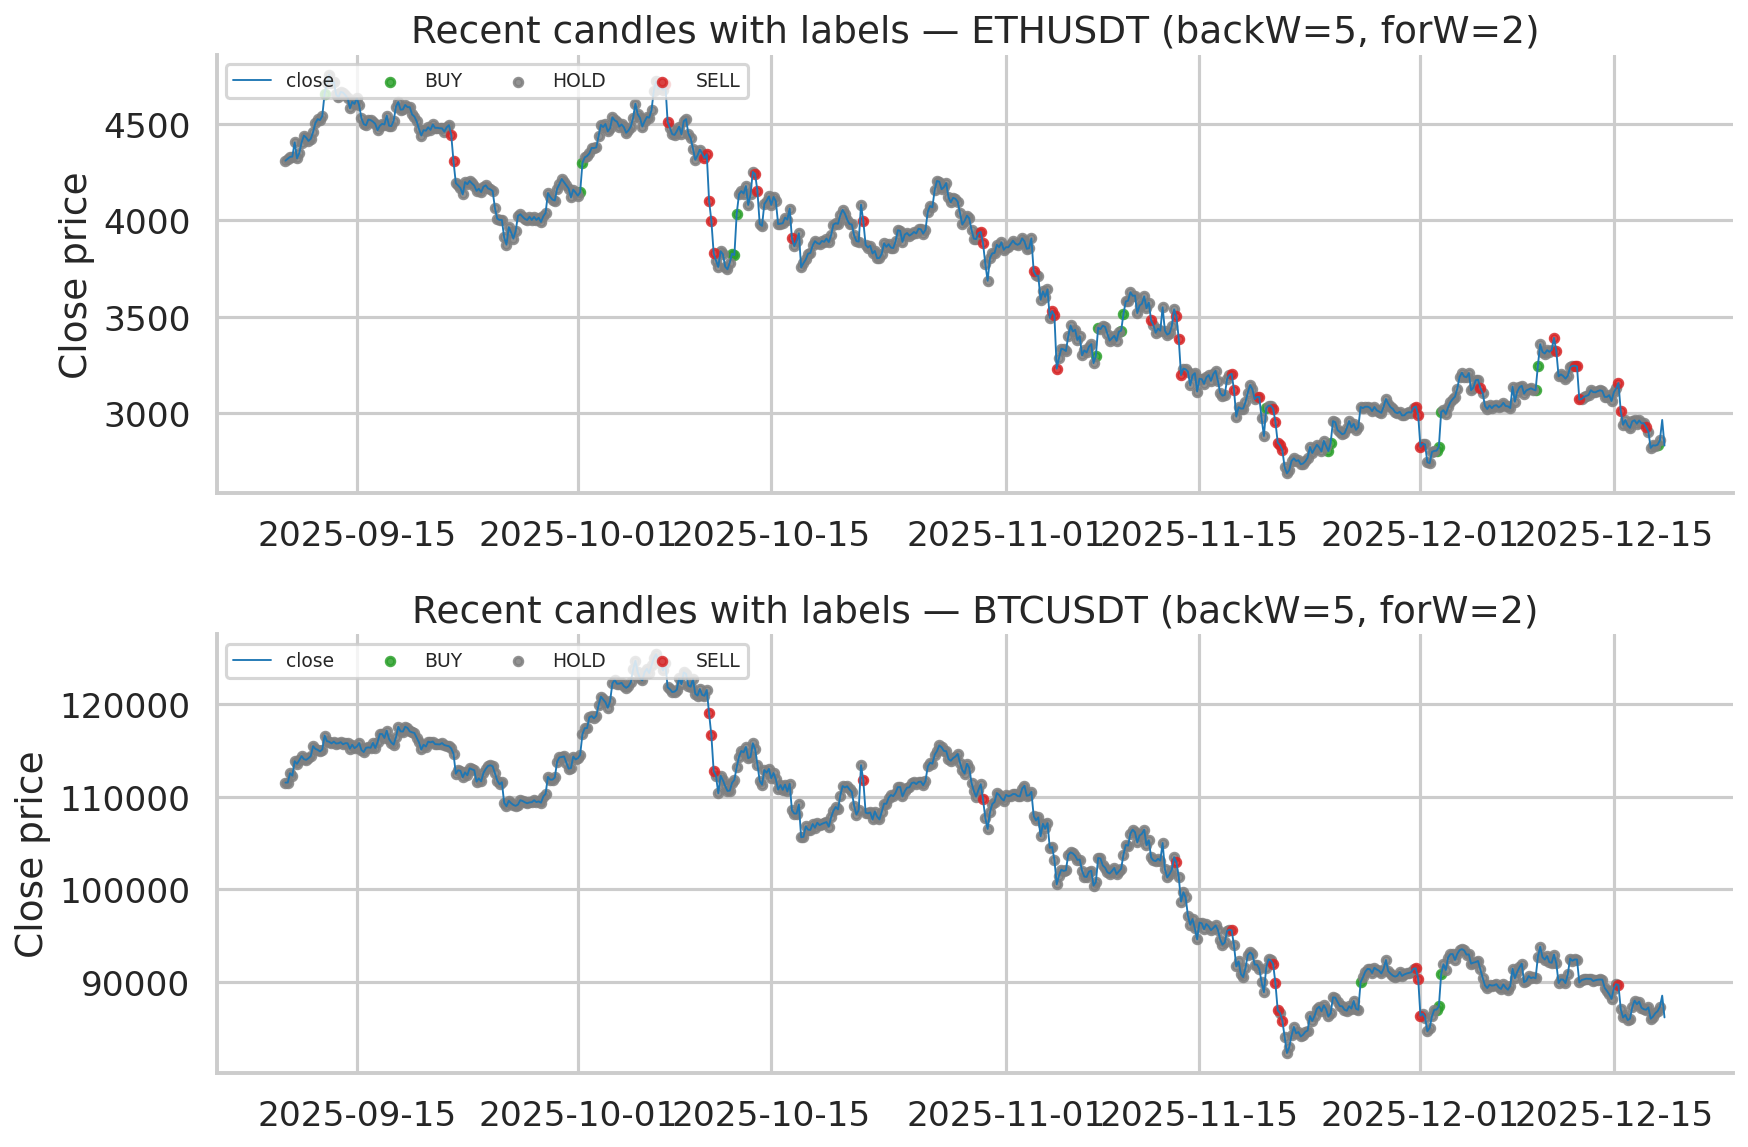

Saved /home/kamil/binance-bot/data/charts_stage2/window_examples_stage2.png


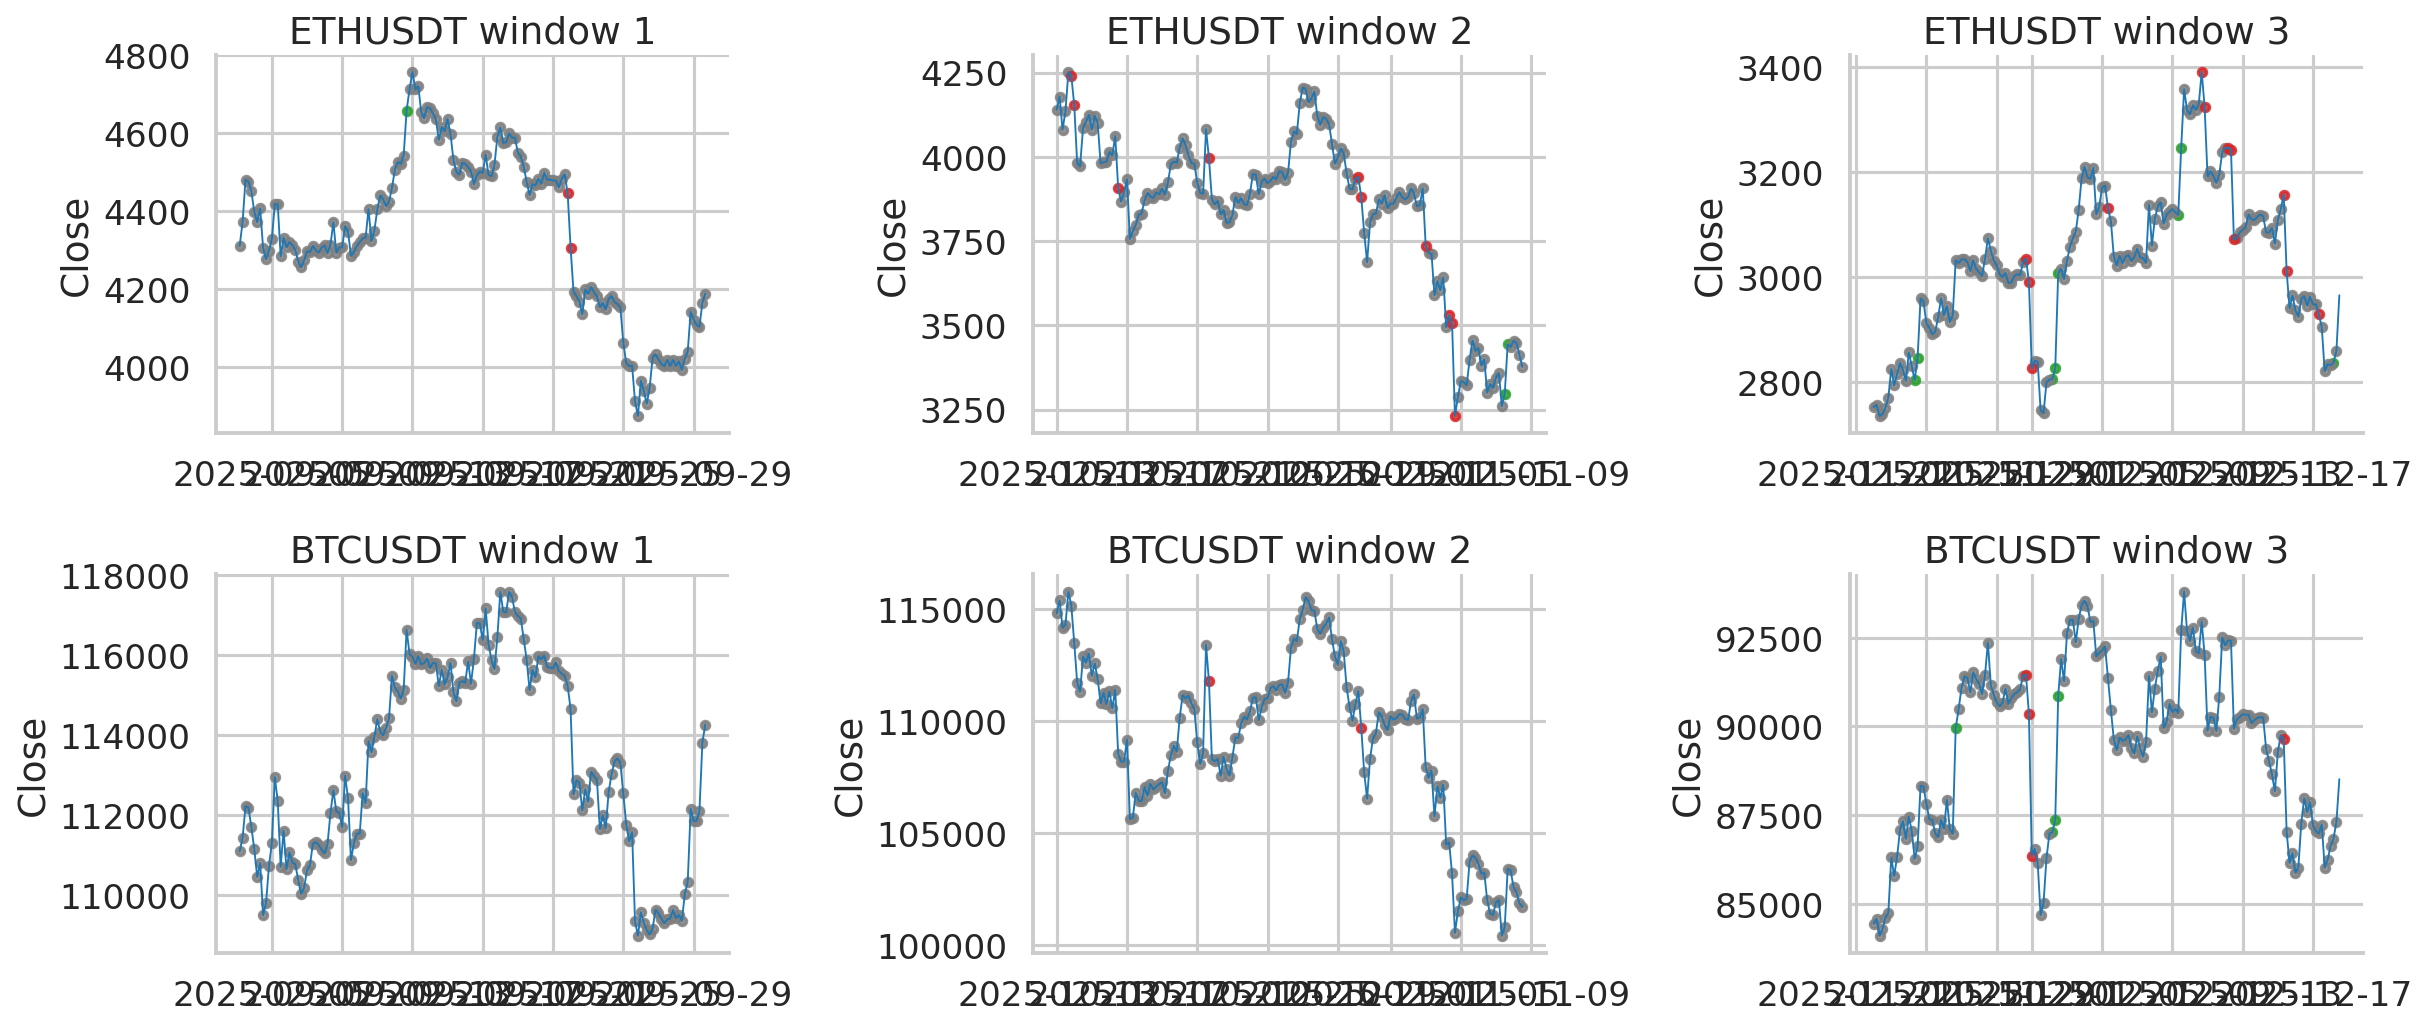

Saved /home/kamil/binance-bot/data/charts_stage2/label_tape_recent.png


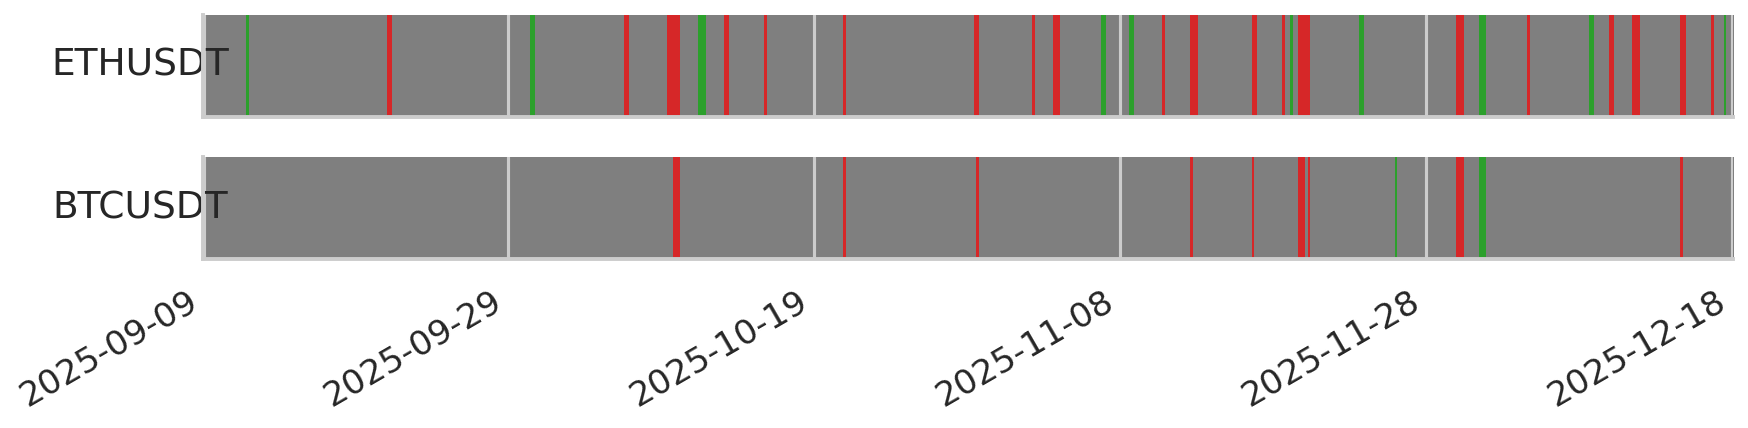

Saved /home/kamil/binance-bot/data/charts_stage2/recent_label_mix.png


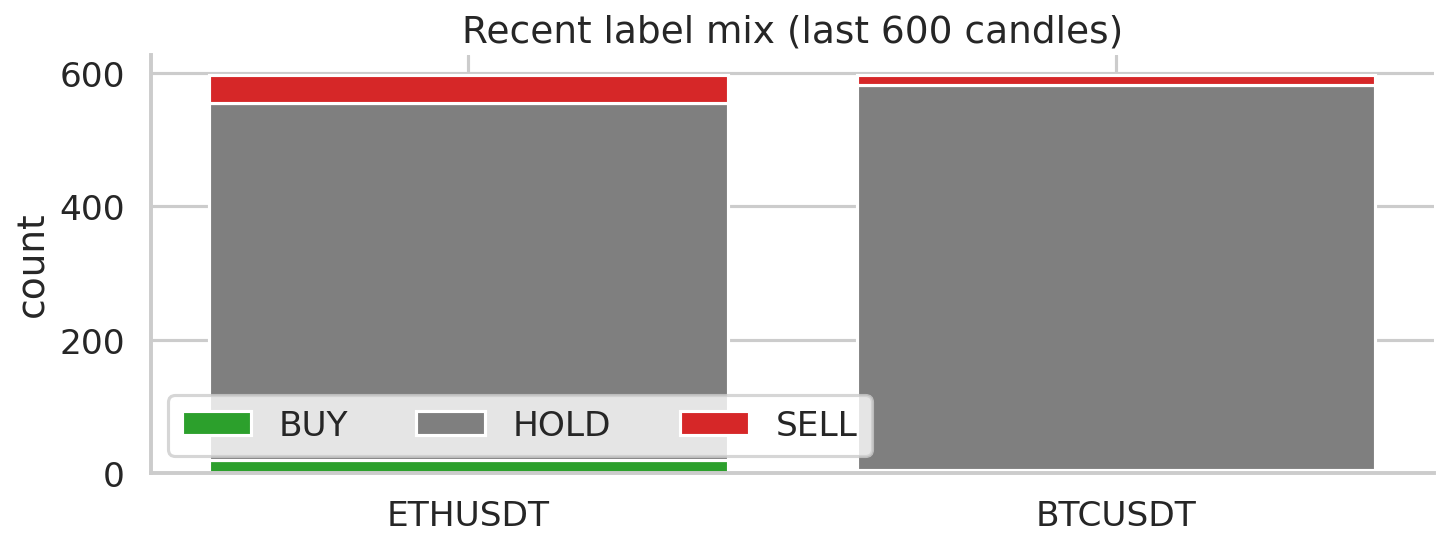

In [ ]:
label_colors = {"BUY": "#2ca02c", "HOLD": "#7f7f7f", "SELL": "#d62728"}
RECENT_LOOKBACK = 600
TARGET_BACKW = DEFAULT_BACKW
TARGET_FORW = DEFAULT_FORW

window_df = report_df[(report_df["backW"] == TARGET_BACKW) & (report_df["forW"] == TARGET_FORW)]
if window_df.empty:
    raise ValueError(f"No reports found for backW={TARGET_BACKW} and forW={TARGET_FORW}.")

window_rows = {}
for symbol in sample_symbols:
    candidates = window_df[window_df["symbol"] == symbol]
    if candidates.empty:
        print(f"Missing backW={TARGET_BACKW}/forW={TARGET_FORW} for {symbol}")
        continue
    window_rows[symbol] = candidates.sort_values("n_valid", ascending=False).iloc[0]

if not window_rows:
    raise ValueError("No symbols available for the requested window.")

merged_by_symbol = {}
for symbol, row in window_rows.items():
    ds_path_value = row.get("dataset_path")
    ds_path = Path(ds_path_value) if isinstance(ds_path_value, str) else None
    if ds_path is None or not ds_path.exists():
        ds_path = DATASETS_DIR / f"{symbol}_{interval_safe}_backW{TARGET_BACKW}_forW{TARGET_FORW}.parquet"
    if not ds_path.exists():
        print(f"Missing dataset for {symbol}: {ds_path}")
        continue
    ds = pd.read_parquet(ds_path)
    ds["ts"] = pd.to_datetime(ds["ts"], utc=True)
    merged = price_dfs[symbol].join(ds.set_index("ts")["label"], how="left")
    merged_by_symbol[symbol] = merged

if not merged_by_symbol:
    raise ValueError("No merged datasets available for recent candle visuals.")

fig, axes = plt.subplots(len(merged_by_symbol), 1, figsize=(12, 4 * len(merged_by_symbol)), sharex=False)
if len(merged_by_symbol) == 1:
    axes = [axes]

for ax, (symbol, merged) in zip(axes, merged_by_symbol.items()):
    recent = merged.iloc[-RECENT_LOOKBACK:]
    ax.plot(recent.index, recent["close"], color="tab:blue", lw=0.9, label="close")
    for label, color in label_colors.items():
        subset = recent[recent["label"] == label]
        ax.scatter(subset.index, subset["close"], s=16, color=color, label=label, alpha=0.85)
    ax.set_title(f"Recent candles with labels — {symbol} (backW={TARGET_BACKW}, forW={TARGET_FORW})")
    ax.set_ylabel("Close price")
    ax.legend(loc="upper left", ncol=4, fontsize=9)

savefig(fig, "recent_candles.png")

# Window examples (multiple slices)
SEGMENT_LEN = 160
SEGMENTS = 3

rows = len(merged_by_symbol)
fig, axes = plt.subplots(rows, SEGMENTS, figsize=(5.5 * SEGMENTS, 3.6 * rows), sharex=False)
if rows == 1:
    axes = [axes]

for row_idx, (symbol, merged) in enumerate(merged_by_symbol.items()):
    row_axes = axes[0] if rows == 1 else axes[row_idx]
    total = len(merged)
    start_base = max(0, total - SEGMENT_LEN * (SEGMENTS + 1))
    starts = np.linspace(start_base, total - SEGMENT_LEN - 1, SEGMENTS, dtype=int)
    for col_idx, start in enumerate(starts):
        ax = row_axes[col_idx]
        segment = merged.iloc[start : start + SEGMENT_LEN]
        ax.plot(segment.index, segment["close"], color="tab:blue", lw=0.9)
        for label, color in label_colors.items():
            subset = segment[segment["label"] == label]
            ax.scatter(subset.index, subset["close"], s=16, color=color, alpha=0.85)
        ax.set_title(f"{symbol} window {col_idx + 1}")
        ax.set_ylabel("Close")

savefig(fig, "window_examples_stage2.png")

# Label tape (film-friendly)
label_to_int = {"BUY": 0, "HOLD": 1, "SELL": 2}
label_cmap = ListedColormap([label_colors["BUY"], label_colors["HOLD"], label_colors["SELL"]])

fig, axes = plt.subplots(len(merged_by_symbol), 1, figsize=(12, 1.6 * len(merged_by_symbol)), sharex=True)
if len(merged_by_symbol) == 1:
    axes = [axes]

for idx, (ax, (symbol, merged)) in enumerate(zip(axes, merged_by_symbol.items())):
    recent = merged.iloc[-RECENT_LOOKBACK:]
    label_vals = recent["label"].map(label_to_int).fillna(1).astype(int).values
    ax.imshow(label_vals[np.newaxis, :], aspect="auto", cmap=label_cmap, interpolation="nearest")
    ax.set_yticks([])
    ax.set_ylabel(symbol, rotation=0, labelpad=30, va="center")
    if idx < len(merged_by_symbol) - 1:
        ax.set_xticks([])
    else:
        ticks = np.linspace(0, len(recent) - 1, 6, dtype=int)
        ax.set_xticks(ticks)
        ax.set_xticklabels(recent.index[ticks].strftime("%Y-%m-%d"), rotation=30, ha="right")

savefig(fig, "label_tape_recent.png")

# Recent label mix (stacked)
recent_mix = []
for symbol, merged in merged_by_symbol.items():
    recent = merged.iloc[-RECENT_LOOKBACK:]
    counts = recent["label"].value_counts()
    recent_mix.append({
        "symbol": symbol,
        "BUY": int(counts.get("BUY", 0)),
        "HOLD": int(counts.get("HOLD", 0)),
        "SELL": int(counts.get("SELL", 0)),
    })

recent_mix_df = pd.DataFrame(recent_mix).set_index("symbol")
fig, ax = plt.subplots(figsize=(10, 4))
bottom = np.zeros(len(recent_mix_df))
for label, color in label_colors.items():
    values = recent_mix_df[label].values
    ax.bar(recent_mix_df.index, values, bottom=bottom, label=label, color=color)
    bottom += values

ax.set_title(f"Recent label mix (last {RECENT_LOOKBACK} candles)")
ax.set_ylabel("count")
ax.legend(ncol=3)

savefig(fig, "recent_label_mix.png")


## Extreme move timeline
Global extremes based on pooled forward returns (per `forW`), then mapped onto recent price series.


Saved /home/kamil/binance-bot/data/charts_stage2/extreme_move_timeline.png


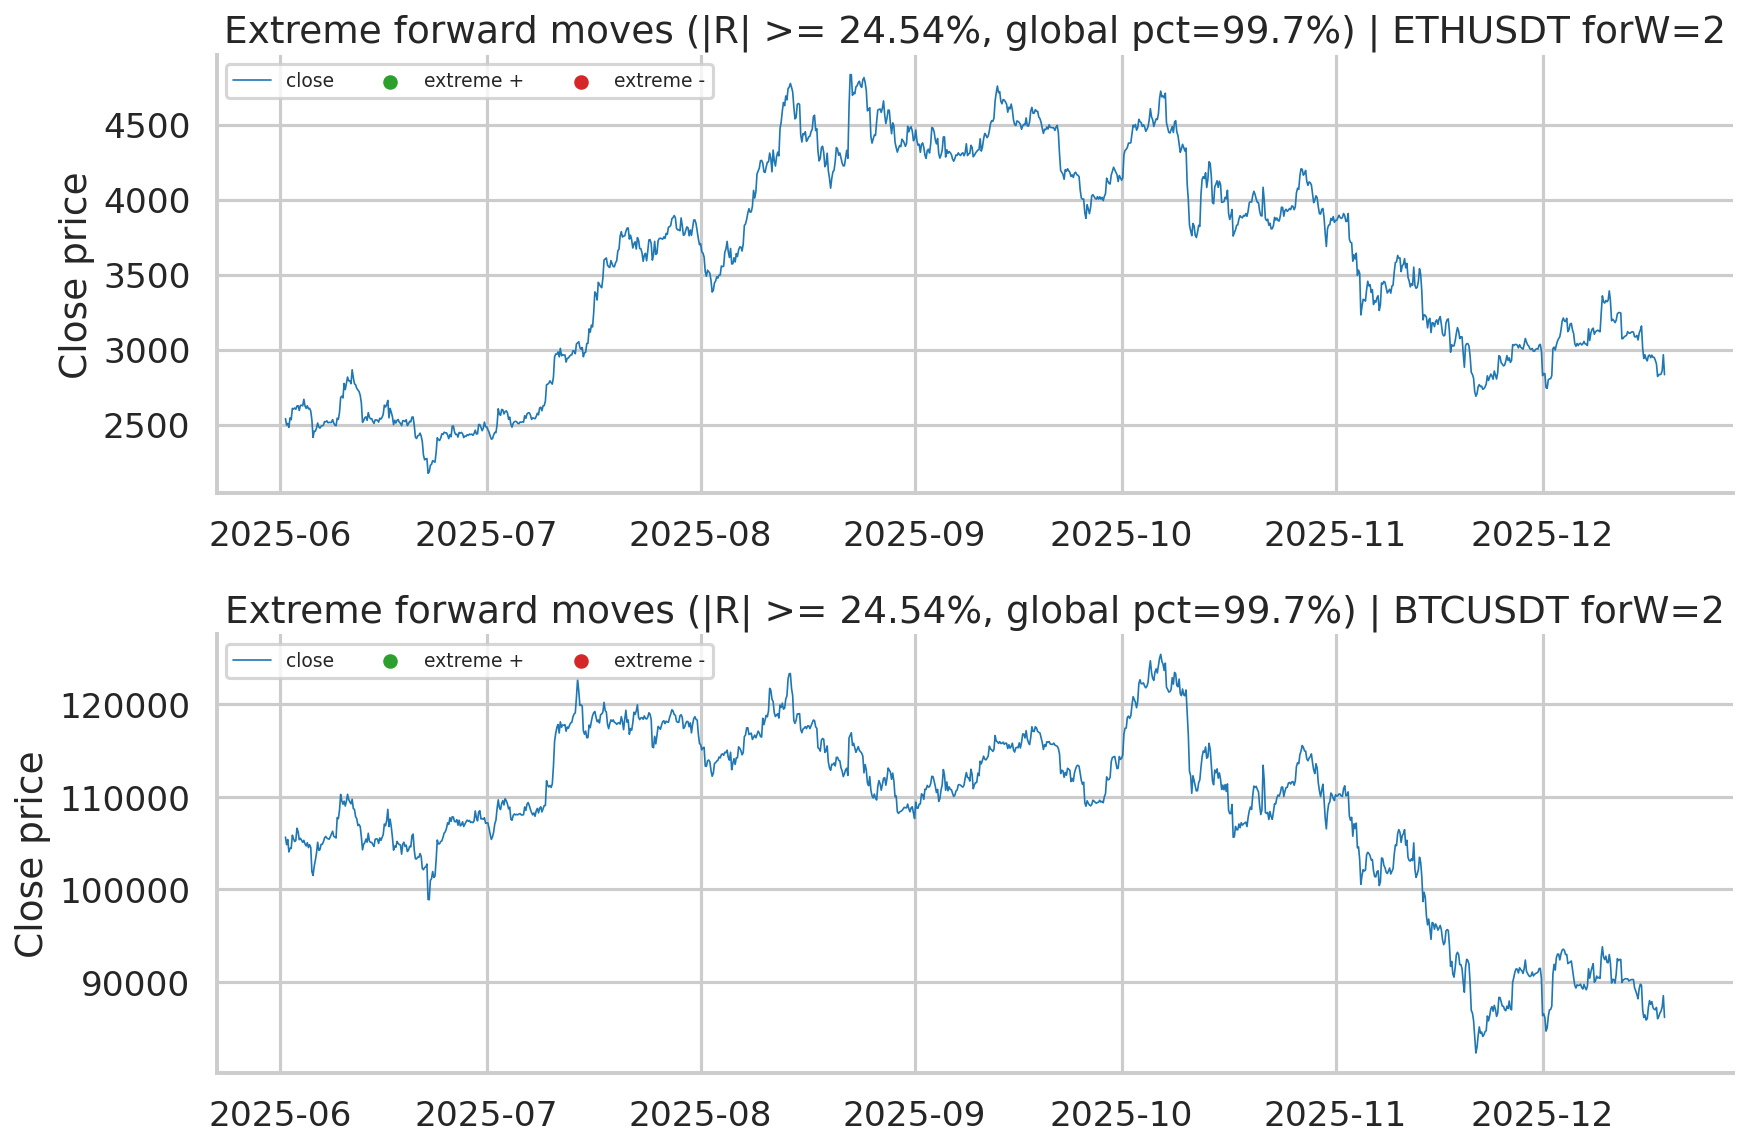

Saved /home/kamil/binance-bot/data/charts_stage2/extreme_event_rates.png


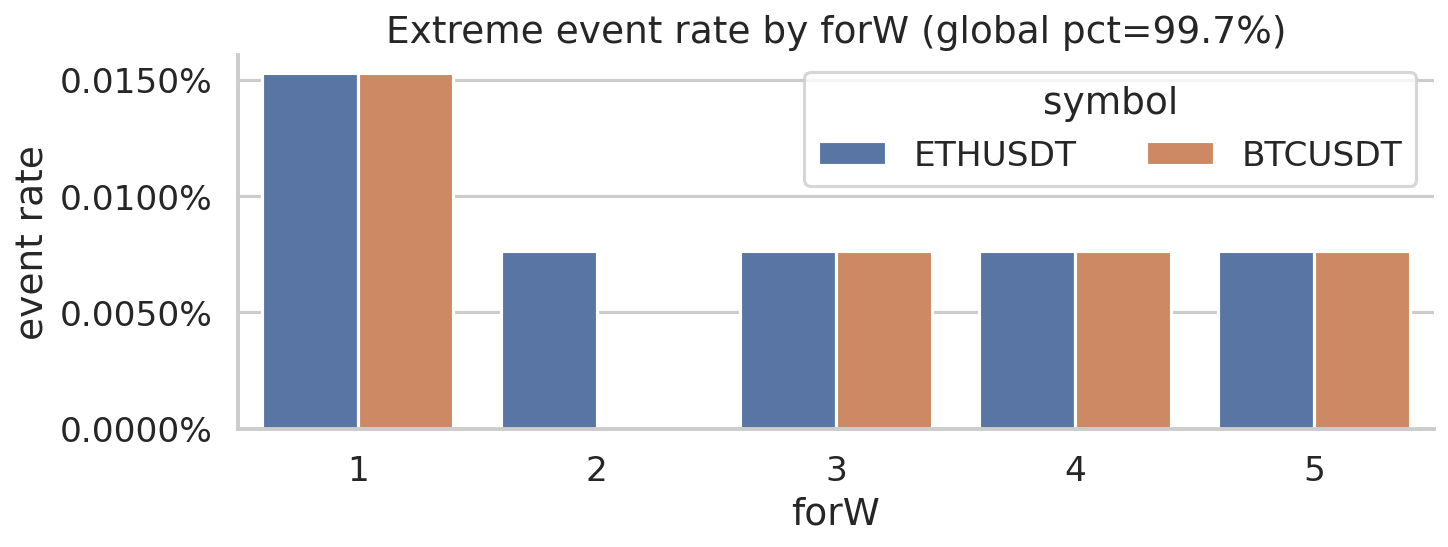

In [ ]:
EXTREME_PCT = 0.997  # global percentile cut
EXTREME_LOOKBACK = 1200
extreme_forW = DEFAULT_FORW if DEFAULT_FORW in forW_values else (max(forW_values) if forW_values else int(sample_row["forW"]))

abs_pool = pooled_abs_by_forW.get(extreme_forW, pd.Series(dtype="float64"))
if abs_pool.empty:
    raise ValueError(f"No pooled returns available for forW={extreme_forW}.")

global_cut = float(abs_pool.quantile(EXTREME_PCT))

fig, axes = plt.subplots(len(sample_symbols), 1, figsize=(12, 4 * len(sample_symbols)), sharex=False)
if len(sample_symbols) == 1:
    axes = [axes]

for ax, symbol in zip(axes, sample_symbols):
    df = price_dfs[symbol]
    series = forward_returns(df, extreme_forW, fee).dropna()
    if series.empty:
        continue
    cut = global_cut
    recent_price = df.iloc[-EXTREME_LOOKBACK:]
    events = series[series.abs() >= cut]
    events = events.loc[events.index.intersection(recent_price.index)]

    ax.plot(recent_price.index, recent_price["close"], color="tab:blue", lw=0.8, label="close")
    pos = events[events > 0]
    neg = events[events < 0]
    ax.scatter(pos.index, recent_price.loc[pos.index, "close"], s=30, color="tab:green", label="extreme +")
    ax.scatter(neg.index, recent_price.loc[neg.index, "close"], s=30, color="tab:red", label="extreme -")
    ax.set_title(
        f"Extreme forward moves (|R| >= {cut:.2%}, global pct={EXTREME_PCT:.1%}) | {symbol} forW={extreme_forW}"
    )
    ax.set_ylabel("Close price")
    ax.legend(loc="upper left", ncol=3, fontsize=9)

savefig(fig, "extreme_move_timeline.png")

# Extreme event rates by forW (global thresholds)
cut_by_forW = {}
for forW in forW_values:
    abs_series = pooled_abs_by_forW.get(forW, pd.Series(dtype="float64"))
    if abs_series.empty:
        continue
    cut_by_forW[forW] = float(abs_series.quantile(EXTREME_PCT))

extreme_stats = []
for symbol in sample_symbols:
    df = price_dfs[symbol]
    for forW in forW_values:
        series = forward_returns(df, forW, fee).dropna()
        if series.empty:
            continue
        cut = cut_by_forW.get(forW)
        if cut is None:
            continue
        count = int((series.abs() >= cut).sum())
        rate = count / len(series)
        extreme_stats.append({
            "symbol": symbol,
            "forW": forW,
            "rate": rate,
            "count": count,
        })

extreme_df = pd.DataFrame(extreme_stats)
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=extreme_df, x="forW", y="rate", hue="symbol", ax=ax)
ax.set_title(f"Extreme event rate by forW (global pct={EXTREME_PCT:.1%})")
ax.set_ylabel("event rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(title="symbol", ncol=2)

savefig(fig, "extreme_event_rates.png")


## Extreme movement percentiles
Table of high percentiles for |forward returns| to understand tail risk / extreme moves.


Saved /home/kamil/binance-bot/data/charts_stage2/tail_percentiles.png


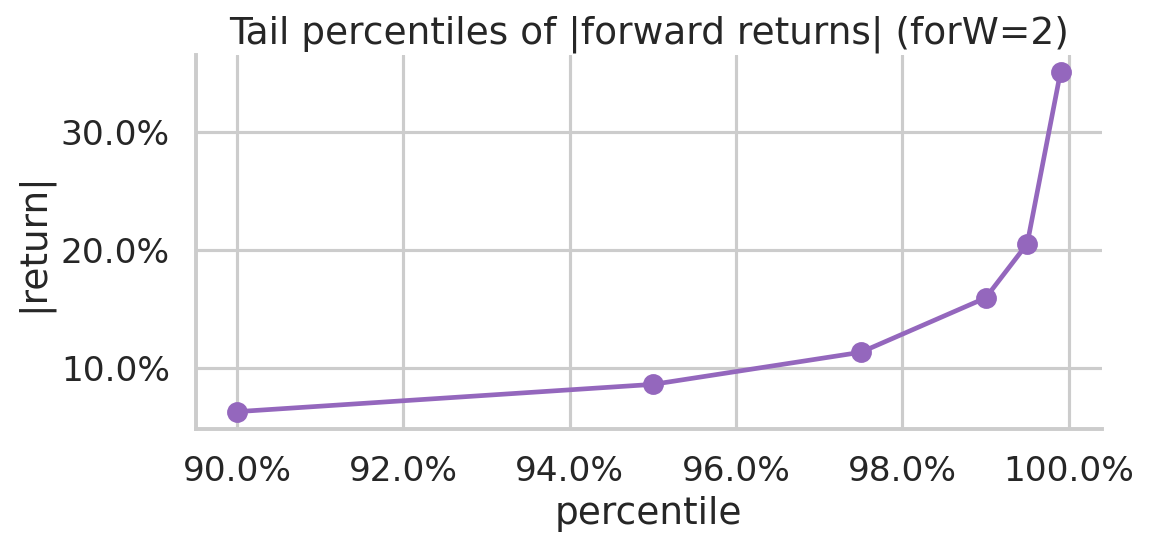

,percentile,abs_return
0,0.900,0.062936
1,0.950,0.086028
2,0.975,0.113229
3,0.990,0.159267
4,0.995,0.205135
5,0.999,0.350474


In [ ]:
tail_percentiles = [0.90, 0.95, 0.975, 0.99, 0.995, 0.999]

TAIL_FORW = extreme_forW if "extreme_forW" in globals() else VISUAL_FORW
tail_abs = pooled_abs_by_forW.get(TAIL_FORW, pooled_abs_returns)

quantiles = tail_abs.quantile(tail_percentiles)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tail_percentiles, quantiles.values, marker="o", color="tab:purple")
ax.set_title(f"Tail percentiles of |forward returns| (forW={TAIL_FORW})")
ax.set_xlabel("percentile")
ax.set_ylabel("|return|")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

savefig(fig, "tail_percentiles.png")

quantiles_df = quantiles.reset_index()
quantiles_df.columns = ["percentile", "abs_return"]
quantiles_df
